In [1]:
import jax
import jax.numpy as jnp
from jax import random
import numpyro
import numpyro.distributions as dist
from numpyro import plate
from numpyro.distributions import constraints
import torch

/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np
from itertools import product, accumulate
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import umap  
from functools import reduce
from tqdm import trange
from typing import List, Dict, Any, Tuple
import copy
import time

In [3]:
def select_most_diverse(samples: jnp.ndarray, num_select: int = 3):
    """
    samples: (N, D)
    returns: python list of selected indices
    """
    N = samples.shape[0]
    selected = [0]

    # pairwise Euclidean distances
    diff = samples[:, None, :] - samples[None, :, :]   # (N, N, D)
    dist_matrix = jnp.linalg.norm(diff, axis=-1)      # (N, N)

    for _ in range(num_select - 1):
        dist_to_selected = dist_matrix[jnp.array(selected), :]  # (len(selected), N)
        min_dist = dist_to_selected.min(axis=0)                # (N,)

        # Set already selected indices to -1 so they won't be picked
        min_dist = min_dist.at[jnp.array(selected)].set(-1.0)
        next_idx = int(jnp.argmax(min_dist))
        selected.append(next_idx)

    return selected

def generate_distinct_distributions(key, N, V, concent=0.8):
    """
    Draw N samples from Dirichlet(alpha).
    - If concent is scalar → alpha = concent * ones(V)
    - If concent is vector of shape (V,) → use directly
    Returns: (N, V)
    """
    if jnp.ndim(concent) == 0:  # scalar
        alpha = jnp.ones((V,), dtype=jnp.float32) * float(concent)
    else:  # vector
        alpha = jnp.array(concent, dtype=jnp.float32)
        assert alpha.shape[0] == V, f"alpha length {alpha.shape[0]} != V={V}"

    alpha = jnp.clip(alpha, a_min=1e-6)
    keys = random.split(key, N)
    samples = jnp.stack([random.dirichlet(k, alpha) for k in keys], axis=0)
    return samples

def generate_distinct_components(key, K, V, peak_strength=5.0, base_concent=0.1):
    """
    Create K component-word distributions (K, V) with a 'peak' at index k * V // K
    """
    comps = []
    keys = random.split(key, K)
    for k in range(K):
        alpha = jnp.ones((V,), dtype=jnp.float32) * base_concent
        alpha = alpha.at[(k * V) // K].set(peak_strength)
        comps.append(random.dirichlet(keys[k], alpha))
    return jnp.stack(comps, axis=0)  # (K, V)

def generate_hierarchical_mixture_data_jax(
    struct_upbd,
    N_per_base: int = 20,
    M: int = 200,
    V: int = 100,
    seed: int = 42,
):
    """
    Returns a dict similar to your PyTorch version, using JAX arrays.
    """
    key = random.PRNGKey(seed)
    num_super = struct_upbd["G1"]
    num_base_per_super = struct_upbd["G2"]
    num_features = struct_upbd["G0"]
    samples_per_base = N_per_base

    # y means and stds
    y_means = jnp.linspace(-num_features / 4, num_features / 4, num=num_features)
    key, sub = random.split(key)
    y_stds = 0.1 + 0.1 * random.uniform(sub, shape=(num_features,))

    alpha_1 = 0.8
    assert num_features >= num_base_per_super * num_super
    super_window = int(num_features / num_super)

    # generate super_core: shape (num_super, super_window)
    key, sub = random.split(key)
    super_core = generate_distinct_distributions(sub, num_super, super_window, concent=alpha_1)

    # build super_prototypes (num_super, num_features)
    blocks = int(num_features / super_window)
    super_prototypes = jnp.zeros((num_super, num_features))
    for i in range(blocks):
        mask = (jnp.arange(num_super) % blocks) == i  # (num_super,)
        mask = mask.astype(jnp.float32)[:, None]      # (num_super, 1)
        block_vals = super_core * mask
        super_prototypes = super_prototypes.at[:, i * super_window:(i + 1) * super_window].set(block_vals)

    # normalize
    super_prototypes = super_prototypes / super_prototypes.sum(axis=-1, keepdims=True)

    # alpha_2 cycling
    alpha_2 = [6, 8] * ((num_super + 1) // 2)
    alpha_2 = alpha_2[:num_super]

    # base prototypes
    base_prototypes_list = []
    for super_id in range(num_super):
        key, sub = random.split(key)
        candids = generate_distinct_distributions(
            sub, num_base_per_super * 5, num_features,
            concent=alpha_2[super_id] * super_prototypes[super_id]
        )
        sel = select_most_diverse(candids, num_select=num_base_per_super)
        chosen = candids[jnp.array(sel), :]
        base_prototypes_list.append(chosen)

    base_prototypes = jnp.stack(base_prototypes_list, axis=0)  # (num_super, num_base_per_super, num_features)

    # word components
    key, sub = random.split(key)
    word_dists = generate_distinct_components(sub, num_features, V, peak_strength=1.0, base_concent=0.1)

    # apply overlapping mask scheme
    word_block = int(V / (num_super * num_base_per_super))
    overlap = int(word_block / 2) if word_block >= 2 else 0
    masks = jnp.zeros_like(word_dists)
    for i in range(num_features):
        if i < int(num_features / 2):
            idxs = jnp.arange(i * overlap, i * overlap + word_block)
        else:
            idxs = jnp.arange(-(i * overlap + word_block) - 1, -i * overlap - 1)
        idxs = (idxs % V).astype(int)
        mask = jnp.zeros((V,), dtype=jnp.bool_)
        mask = mask.at[idxs].set(True)
        masks = masks.at[i].set(mask.astype(jnp.float32))

    word_dists = word_dists * masks
    row_sums = word_dists.sum(axis=-1, keepdims=True)
    word_dists = word_dists / (row_sums + 1e-12)

    # generate documents
    X_list, y_list, labels_base, labels_super, labels_x, labels_y = [], [], [], [], [], []

    for super_id in range(num_super):
        for base_offset in range(num_base_per_super):
            base_id = super_id * num_base_per_super + base_offset
            base_proto = base_prototypes[super_id, base_offset]

            for _ in range(samples_per_base):
                doc_words = []
                docs_labels = []
                for _w in range(M):
                    key, sub = random.split(key)
                    comp_logits = jnp.log(base_proto + 1e-12)
                    comp_id = int(random.categorical(sub, comp_logits))
                    docs_labels.append(comp_id)
                    key, sub = random.split(key)
                    word_logits = jnp.log(word_dists[comp_id] + 1e-12)
                    word_idx = int(random.categorical(sub, word_logits))
                    doc_words.append(jax.nn.one_hot(word_idx, V))
                doc = jnp.stack(doc_words, axis=0)
                doc_z = jnp.array(docs_labels)
                X_list.append(doc)
                labels_x.append(doc_z)

                key, sub = random.split(key)
                comp_for_y = int(random.categorical(sub, jnp.log(base_proto + 1e-12)))
                labels_y.append(comp_for_y)
                key, sub = random.split(key)
                y_val = y_means[comp_for_y] + y_stds[comp_for_y] * random.normal(sub, shape=())
                y_list.append(y_val)
                labels_base.append(base_id)
                labels_super.append(super_id)

    X_data = jnp.stack(X_list, axis=0)
    y_data = jnp.stack(y_list, axis=0)
    labels_base = jnp.array(labels_base)
    labels_super = jnp.array(labels_super)
    labels_x = jnp.array(labels_x)
    labels_y = jnp.array(labels_y)

    return {
        "x": X_data,
        "y": y_data,
        "super_labels": labels_super,
        "base_labels": labels_base,
        "x_labels": labels_x,
        "y_labels": labels_y,
        "word_dists": word_dists,
        "reg_means": y_means,
        "reg_std": y_stds,
        "super_mix_weights": super_prototypes,
        "child_mix_weights": base_prototypes,
    }

# Example usage
if __name__ == "__main__":
    struct_upbd = {"G0": 36, "G1": 3, "G2": 4}   # example
    data = generate_hierarchical_mixture_data_jax(struct_upbd, N_per_base=3, M=10, V=50, seed=0)
    print("x shape:", data["x"].shape)
    print("y shape:", data["y"].shape)
    print("word_dists shape:", data["word_dists"].shape)
    print("super mix shape:", data["super_mix_weights"].shape)
    print("child mix shape:", data["child_mix_weights"].shape)


x shape: (36, 10, 50)
y shape: (36,)
word_dists shape: (36, 50)
super mix shape: (3, 36)
child mix shape: (3, 4, 36)


In [4]:
import os
def tsne_visualization(data, struct_upbd, log_dir=None):
    x_agg = data["x"].sum(axis=1) # (N, V)
    # Run t-SNE
    tsne = TSNE(n_components=2, random_state=0)
    x_embedded = tsne.fit_transform(x_agg)
    if log_dir is not None:
        if not os.path.exists(log_dir):
            os.makedirs(log_dir)

    # Plot t-SNE colored by super categories
    for cat in range(len(struct_upbd)-1):
        plt.figure()

        plt.subplot(1, 1, 1)
        scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["labels"][cat], cmap="tab10", s=10)
        plt.colorbar(scatter, ticks=range(6))
        plt.title(f"t-SNE of aggregated x colored by super categories level {cat}")
        plt.xlabel("TSNE 1")
        plt.ylabel("TSNE 2")

        if log_dir is not None:
            plt.savefig(f"{log_dir}/tsne_visualization_level_{cat}.png", dpi=300)
        else:
            plt.show()

    # Plot distribution of y by super categories
    for cat in range(len(struct_upbd)-1):
        plt.figure()
        for super_id in range(struct_upbd[f"G{cat+1}"]):
            y_vals = data["y"][data["labels"][cat] == super_id]
            plt.hist(y_vals, bins=20, alpha=0.5, label=f"Category level {cat} category {super_id}")
        plt.title(f"Distribution of y by Categories level {cat}")
        plt.xlabel("y")
        plt.ylabel("Count")
        plt.legend()
        if log_dir is not None:
            plt.savefig(f"{log_dir}/y_distribution_level_{cat}.png", dpi=300)
        else:   
            plt.show()


In [5]:
import os
import vis
import importlib
importlib.reload(vis)
from vis import plot_bars_for_tensor

def umap_visualization(data, struct_upbd, log_dir=None):
    x_agg = data["x"].sum(axis=1)
    # === UMAP projection ===
    reducer = umap.UMAP(random_state=0)
    x_umap = reducer.fit_transform(x_agg)
    if log_dir is not None:
        if not os.path.exists(log_dir):
            os.makedirs(log_dir)

    # === UMAP Plots ===
    for cat in range(len(struct_upbd)-1):
        plt.figure()

        # Super category coloring
        plt.subplot(1, 1, 1)
        plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["labels"][cat], cmap="tab10", s=10)
        plt.title(f"UMAP by Category level {cat}")
        plt.xlabel("UMAP 1")
        plt.ylabel("UMAP 2")

        if log_dir is not None:
            plt.savefig(f"{log_dir}/umap_visualization_level_{cat}.png", dpi=300)
        else:
            plt.show()

    # === Mixture Component Word Distributions ===
    num_components = struct_upbd["G0"]
    V = data["x"].shape[-1]
    word_dists = data["word_dists"]

    # Bar plots for each component
    for i in range(num_components):
        fig, ax = plt.subplots(1, 1)
        ax.bar(range(V), word_dists[i])
        ax.set_title(f"Component {i}")
        ax.set_xlabel("Word ID")
        ax.set_ylabel("Probability")
        ax.set_ylim(0, word_dists.max().item() * 1.1)

        fig.suptitle(f"Word Distributions of {i}th Shared Mixture Components", fontsize=16)
        if log_dir is not None:
            plt.savefig(f"{log_dir}/word_distributions_{i}.png", dpi=300)
        else:
            plt.show()

    # Bar plots for each component
    for cat in range(len(struct_upbd)-1):
        weights = data["weights"][cat]
        plot_bars_for_tensor(weights, title_prefix=f"Category level {cat} Mixture Weights", 
                             save_dir=log_dir)

In [6]:
def transfer_hierarchy_to_data_labels(local_cats: np.ndarray, level_dims: list[int]) -> np.ndarray:
    """
    Reverse of transfer_data_labels_to_hierarchy.
    Given local_cats and cluster sizes per level, reconstruct absolute labels.

    Args:
        local_cats: (N, L) array of local indices
        level_dims: list of ints, max cluster size per level

    Returns:
        data_labels: (N, L) array of absolute indices per level
    """
    N, L = local_cats.shape
    data_labels = np.zeros((N, L), dtype=np.int32)

    # level 0: absolute = local (super labels)
    data_labels[:, 0] = local_cats[:, 0]

    # deeper levels: absolute id = parent_abs * K[level] + local_id
    for level in range(1, L):
        parent_abs = data_labels[:, level - 1]
        data_labels[:, level] = parent_abs * level_dims[level] + local_cats[:, level]
    
    labels_per_level = [data_labels[:, i] for i in range(L)]

    return labels_per_level


In [7]:
def transfer_state_to_data(state, struct_upbd):
    """
    Given the HDMM state, extract the mixture components and category assignments
    in a format similar to the ground truth data for evaluation.

    Args:
        state: dict, the HDMM state returned by the model function or Gibbs sampler.
        struct_upbd: dict, structure upper bounds.
    Returns:
        data: dict, containing 'word_dists' and 'category_assignments'.
    """
    N = state["words"]["obs"].shape[0]
    data = {}
    data["word_dists"] = state["mixture_components"]["generation"].detach().cpu().numpy()
    data["reg_means"] = state["mixture_components"]["regression_mu"].detach().cpu().numpy()
    data["reg_std"] = state["mixture_components"]["regression_sigma"].detach().cpu().numpy()
    data["labels"] = transfer_hierarchy_to_data_labels(state["local_category_assignments"].detach().cpu().numpy(), list(struct_upbd.values())[1:])
    data["x_labels"] = state["words"]["z_gen"].detach().cpu().numpy()
    data["y_labels"] = state["words"]["z_reg"].detach().cpu().numpy()
    data["x"] = np.array(state["words"]["obs"])
    data["y"] = np.array(state["words"]["reg"])

    # Extract super-cluster mixture weights
    data["weights"] = [state["struct_values"][f"G{i}"].detach().cpu().numpy() for i in range(1, len(struct_upbd))]

    return data

In [8]:
def data_summary(model_return, data, struct_upbd, log_dir=None, tsne=True, umap=True):
    N = data["x"].shape[0]
    
    model_data = transfer_state_to_data(model_return[0], struct_upbd)
    if tsne:
        tsne_visualization(model_data, struct_upbd, log_dir)
    if umap:
        umap_visualization(model_data, struct_upbd, log_dir)
    

In [9]:
struct_upbd = {"G0": 10, "G1": 2, "G2": 3}
data = generate_hierarchical_mixture_data_jax(struct_upbd)

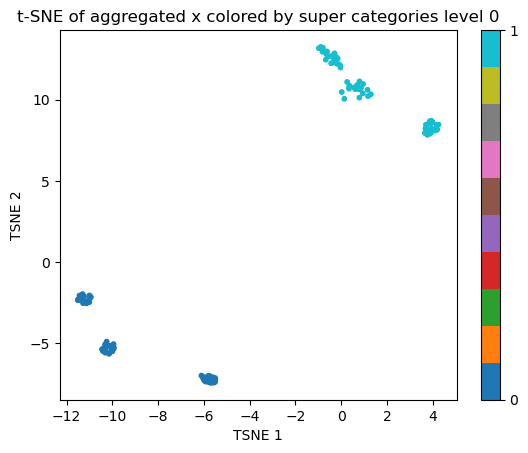

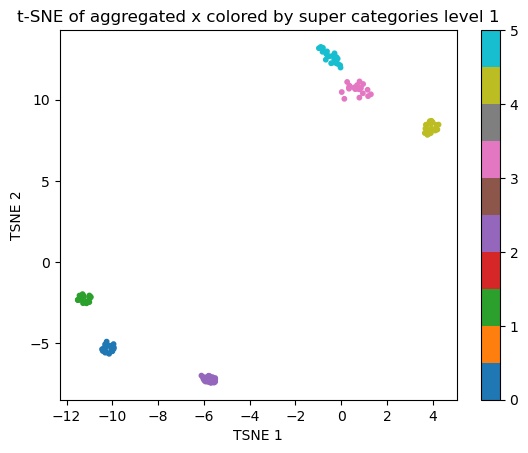

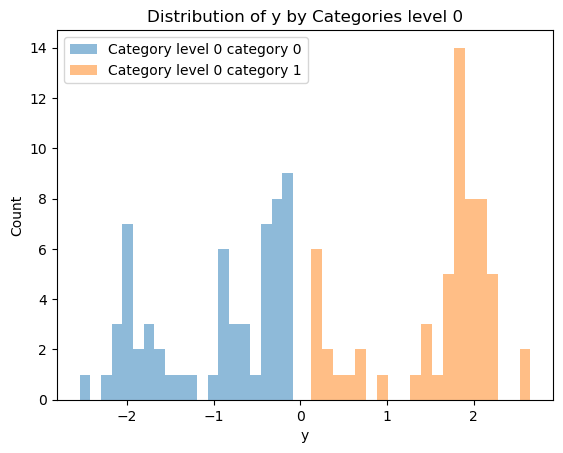

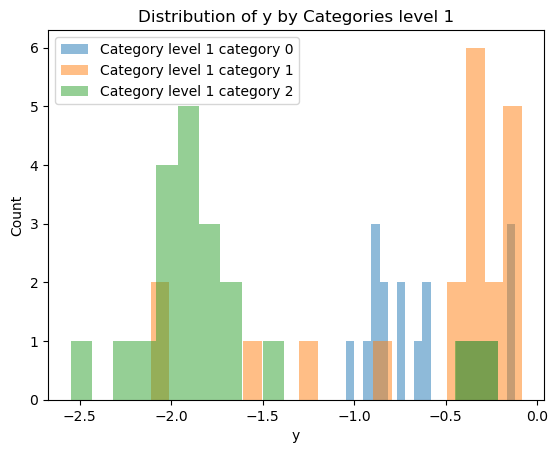

In [10]:
post_state = {
    "struct_params": None,
    "struct_values": {"G1": torch.from_numpy(np.array(data["super_mix_weights"])).to(torch.float32), "G2": torch.from_numpy(np.array(jnp.transpose(data["child_mix_weights"], (1, 0, 2)))).to(torch.float32)},
    "mixture_components": {
        "generation": torch.from_numpy(np.array(data["word_dists"])).to(torch.float32),
        "regression_mu": torch.from_numpy(np.array(data["reg_means"])).to(torch.float32),
        "regression_sigma": torch.from_numpy(np.array(data["reg_std"])).to(torch.float32),
    },
    "local_category_assignments": torch.stack([torch.from_numpy(np.array(data["super_labels"])).to(torch.int64), torch.from_numpy(np.array(data["base_labels"])).to(torch.int64) % struct_upbd["G2"]], dim=1),
    "doc_values": None,
    "words": {
        "z_gen": torch.from_numpy(np.array(data["x_labels"])).to(torch.int64),
        "z_reg": torch.from_numpy(np.array(data["y_labels"])).to(torch.int64),
        "obs": torch.from_numpy(np.array(data["x"])).to(torch.float32),
        "reg": torch.from_numpy(np.array(data["y"])).to(torch.float32),
    },
}
model_return = (post_state, None)
struct_upbd = {"G0": 10, "G1": 2, "G2": 3}
data_summary(model_return, data, struct_upbd, tsne=True, umap=False)

In [11]:
import vis
import hdmm_torch
import importlib
import hdmm_utils_torch
importlib.reload(vis)
importlib.reload(hdmm_utils_torch)
importlib.reload(hdmm_torch)
from hdmm_torch import HDMM
from vis import likelihood_visualization
import torch
import numpy as np


known_cats = {}
known_cats[0] = torch.from_numpy(np.array(data["super_labels"])).to(torch.int64)
known_cats[1] = torch.from_numpy(np.array(data["base_labels"])).to(torch.int64) % struct_upbd["G2"]  # make sure base labels are in [0, G2-1]
known_mixtures = {}
known_mixtures["generation"] = torch.from_numpy(np.array(data["word_dists"])).to(torch.float32)
known_struct = {0: torch.from_numpy(np.array(data["super_mix_weights"])).to(torch.float32), 1: torch.from_numpy(np.array(jnp.transpose(data["child_mix_weights"], (1, 0, 2)))).to(torch.float32)}
known_struct = {0: known_struct[0]/known_struct[0].sum(dim=-1, keepdim=True), 1: known_struct[1]/known_struct[1].sum(dim=-1, keepdim=True)}
known_words = torch.from_numpy(np.array(data["x_labels"])).to(torch.int64)
known_regs = torch.from_numpy(np.array(data["y_labels"])).to(torch.int64)
known_clusters = {0: torch.ones(struct_upbd["G1"])/struct_upbd["G1"], 1: torch.ones((struct_upbd["G2"], struct_upbd["G1"]))/struct_upbd["G2"]}  # assume we know there are G1 super clusters

# model = HDMM(struct_upbd, vocab_size=100)
# print("Model initialized.")

# z_gen, z_reg, local_category_assignments, doc_values, log_prob = model.infer(torch.from_numpy(np.array(data["x"])).to(torch.float32), reg=torch.from_numpy(np.array(data["y"])).to(torch.float32), num_iters=60)
# print("Inference completed.")


Initialized gamma: 0.7290
Initialized alpha0: Parameter containing:
tensor([0.7414, 0.7414, 0.7414, 0.7414, 0.7414, 0.7414, 0.7414, 0.7414, 0.7414,
        0.7414], requires_grad=True)
Model initialized.


Gibbs Sampling:   0%|          | 0/300 [00:00<?, ?it/s]

Gibbs Sampling (Iter 298) LogProb -36085.29:  99%|█████████▉| 298/300 [00:24<00:00, 11.63it/s]

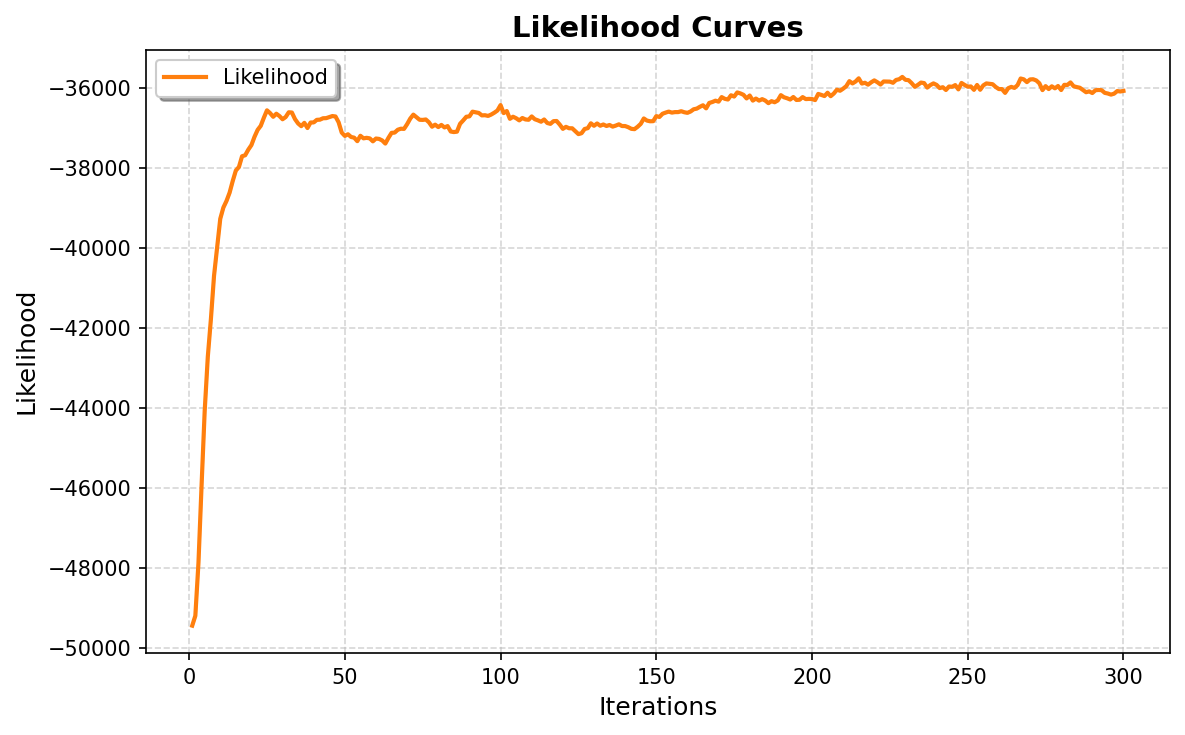

Gibbs Sampling (Iter 299) LogProb -36071.16: 100%|██████████| 300/300 [00:24<00:00, 12.06it/s]


Inference completed.


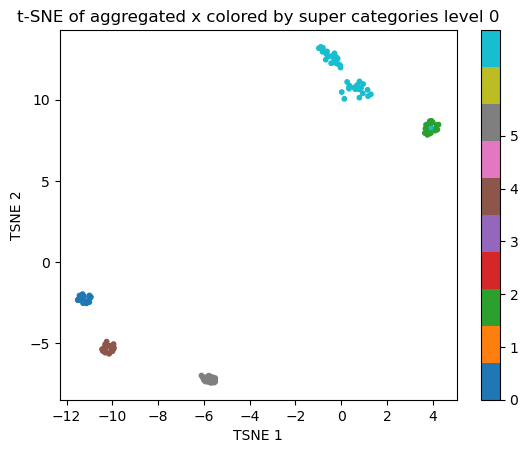

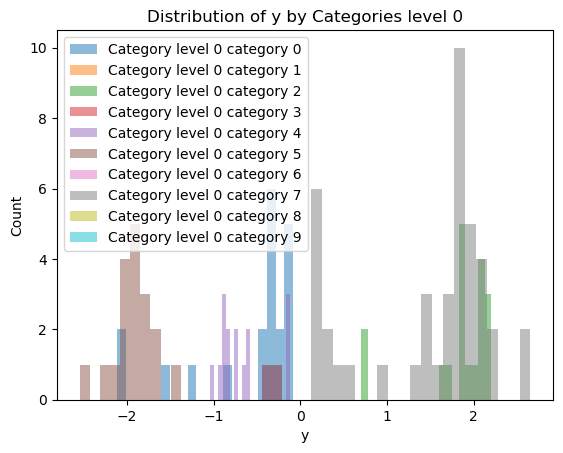

Initialized gamma: 0.7807
Initialized alpha0: Parameter containing:
tensor([0.5887, 0.5887, 0.5887, 0.5887, 0.5887, 0.5887, 0.5887, 0.5887, 0.5887,
        0.5887], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -43791.78:  99%|█████████▉| 298/300 [00:23<00:00, 12.28it/s]

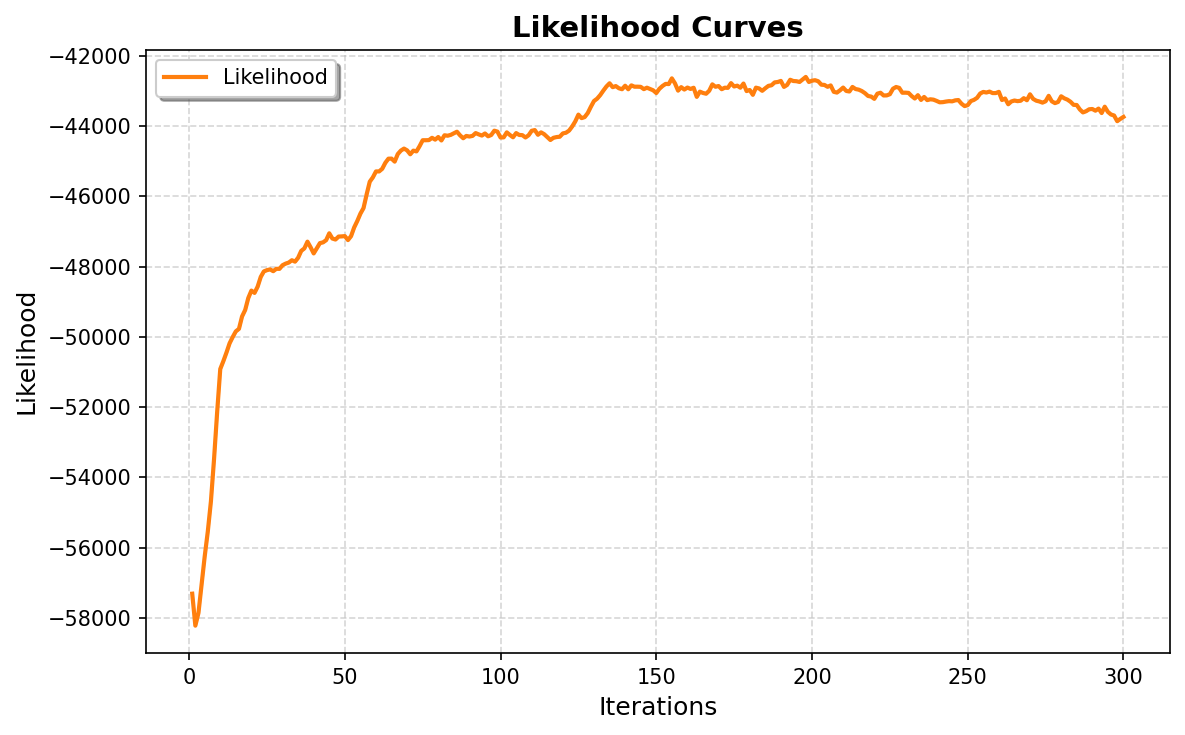

Gibbs Sampling (Iter 299) LogProb -43734.77: 100%|██████████| 300/300 [00:24<00:00, 12.45it/s]


Inference completed.


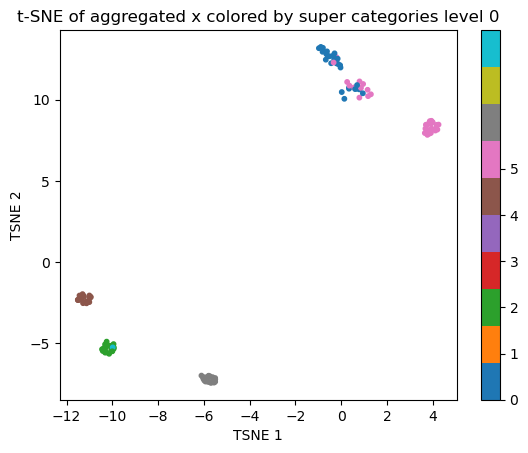

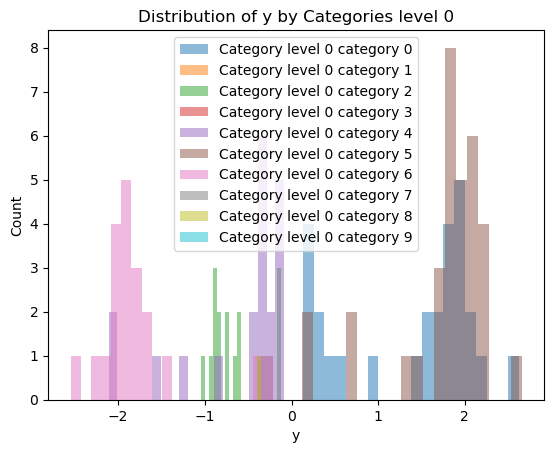

Initialized gamma: 0.9504
Initialized alpha0: Parameter containing:
tensor([0.8732, 0.8732, 0.8732, 0.8732, 0.8732, 0.8732, 0.8732, 0.8732, 0.8732,
        0.8732], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -37721.27:  99%|█████████▉| 298/300 [00:24<00:00, 12.08it/s]

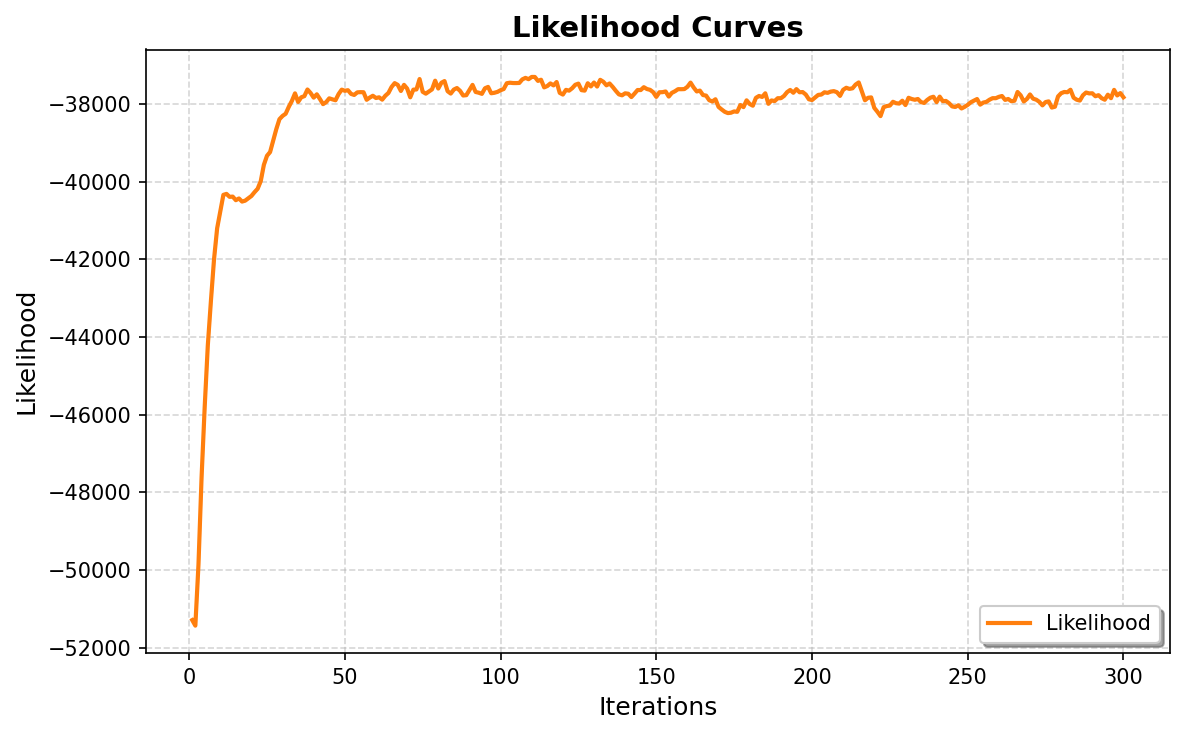

Gibbs Sampling (Iter 299) LogProb -37829.65: 100%|██████████| 300/300 [00:24<00:00, 12.01it/s]


Inference completed.


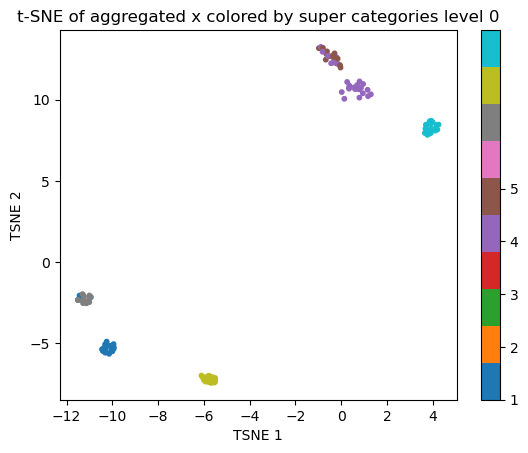

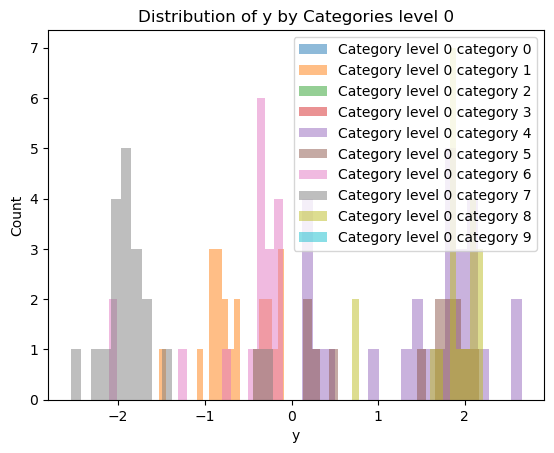

Initialized gamma: 0.6839
Initialized alpha0: Parameter containing:
tensor([0.9331, 0.9331, 0.9331, 0.9331, 0.9331, 0.9331, 0.9331, 0.9331, 0.9331,
        0.9331], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -36887.86:  99%|█████████▉| 298/300 [00:23<00:00, 12.59it/s]

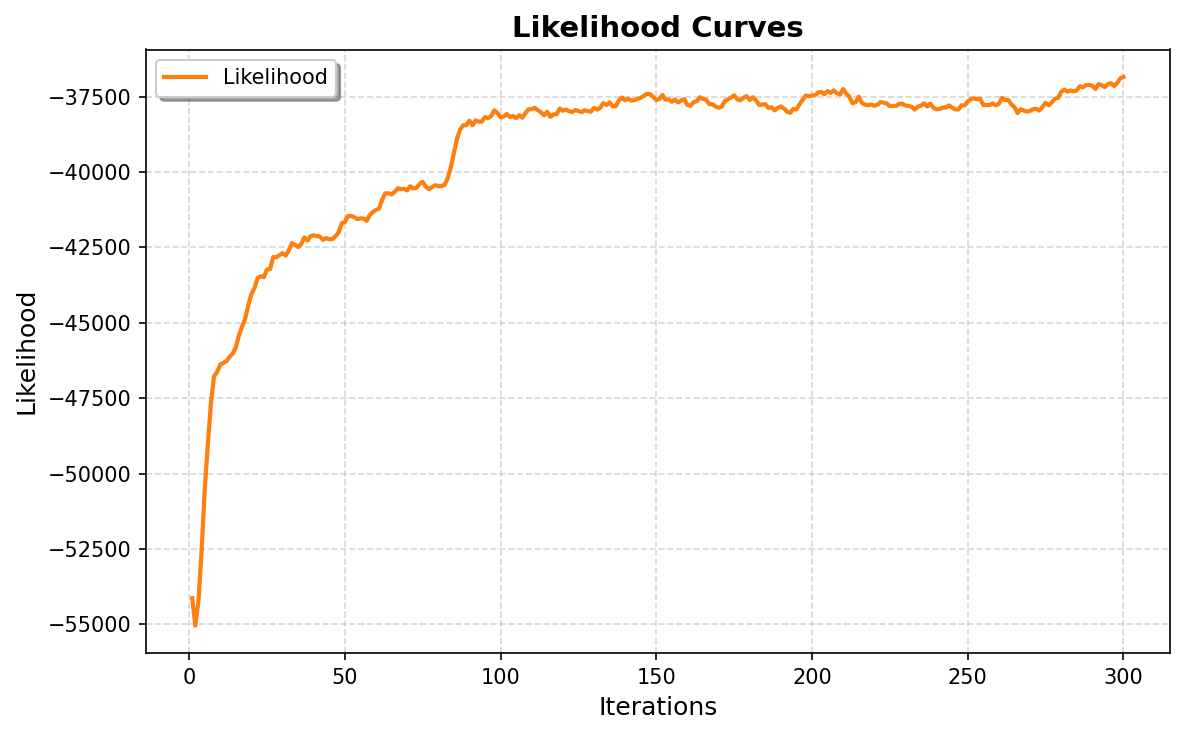

Gibbs Sampling (Iter 299) LogProb -36840.84: 100%|██████████| 300/300 [00:23<00:00, 12.57it/s]


Inference completed.


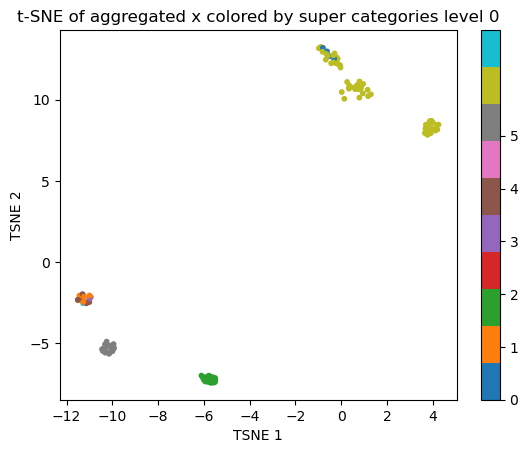

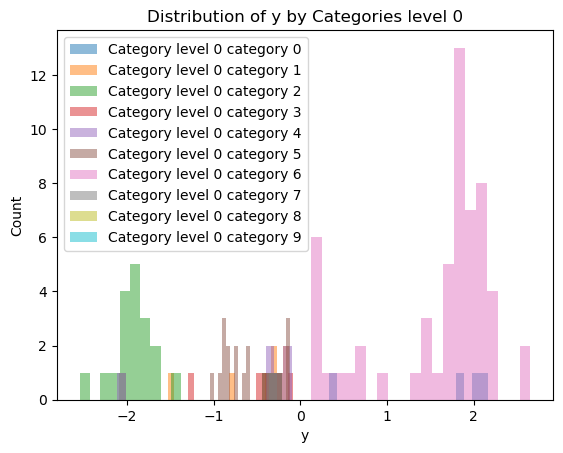

Initialized gamma: 0.8090
Initialized alpha0: Parameter containing:
tensor([0.5343, 0.5343, 0.5343, 0.5343, 0.5343, 0.5343, 0.5343, 0.5343, 0.5343,
        0.5343], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -32157.53:  99%|█████████▉| 298/300 [00:23<00:00, 12.66it/s]

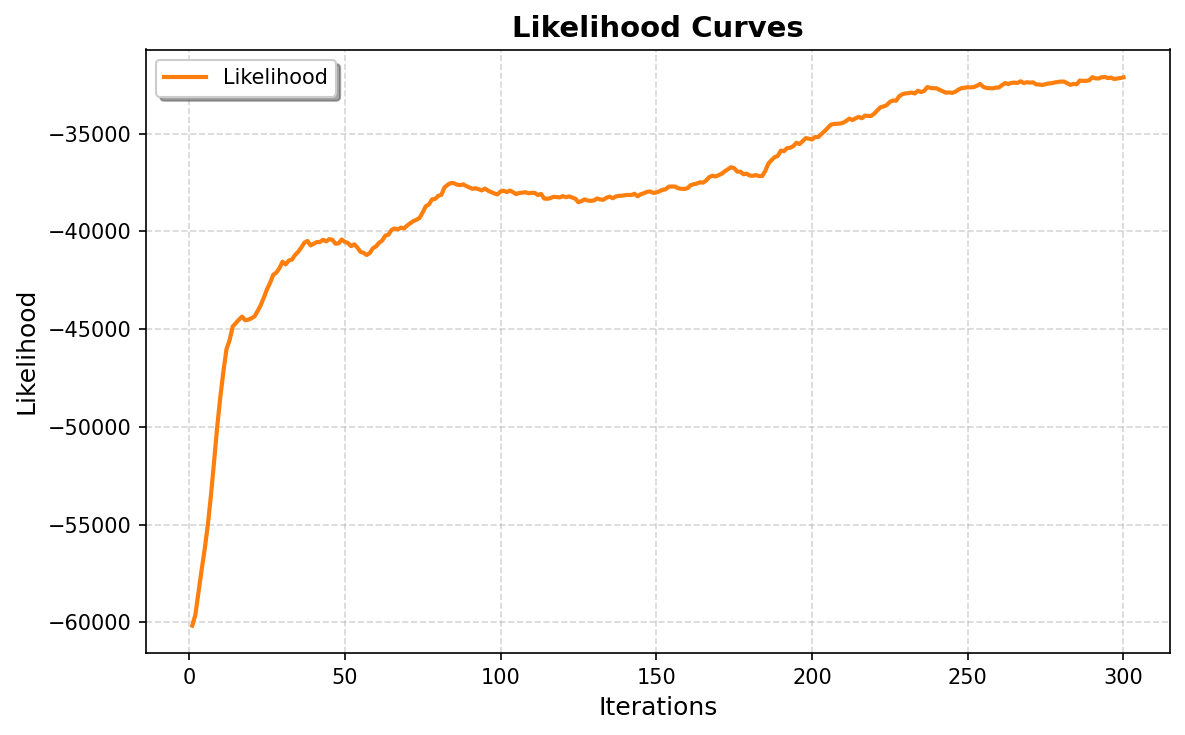

Gibbs Sampling (Iter 299) LogProb -32124.65: 100%|██████████| 300/300 [00:23<00:00, 12.66it/s]


Inference completed.


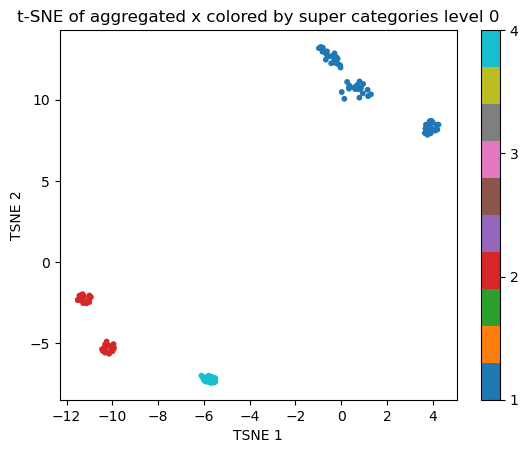

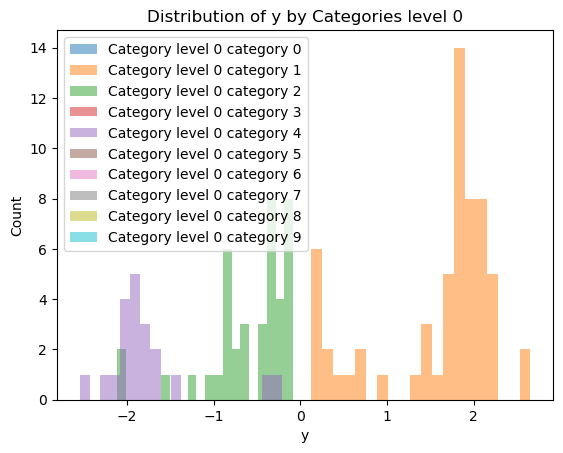

Initialized gamma: 0.5118
Initialized alpha0: Parameter containing:
tensor([0.6554, 0.6554, 0.6554, 0.6554, 0.6554, 0.6554, 0.6554, 0.6554, 0.6554,
        0.6554], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -24219.12:  99%|█████████▉| 298/300 [00:24<00:00, 12.28it/s]

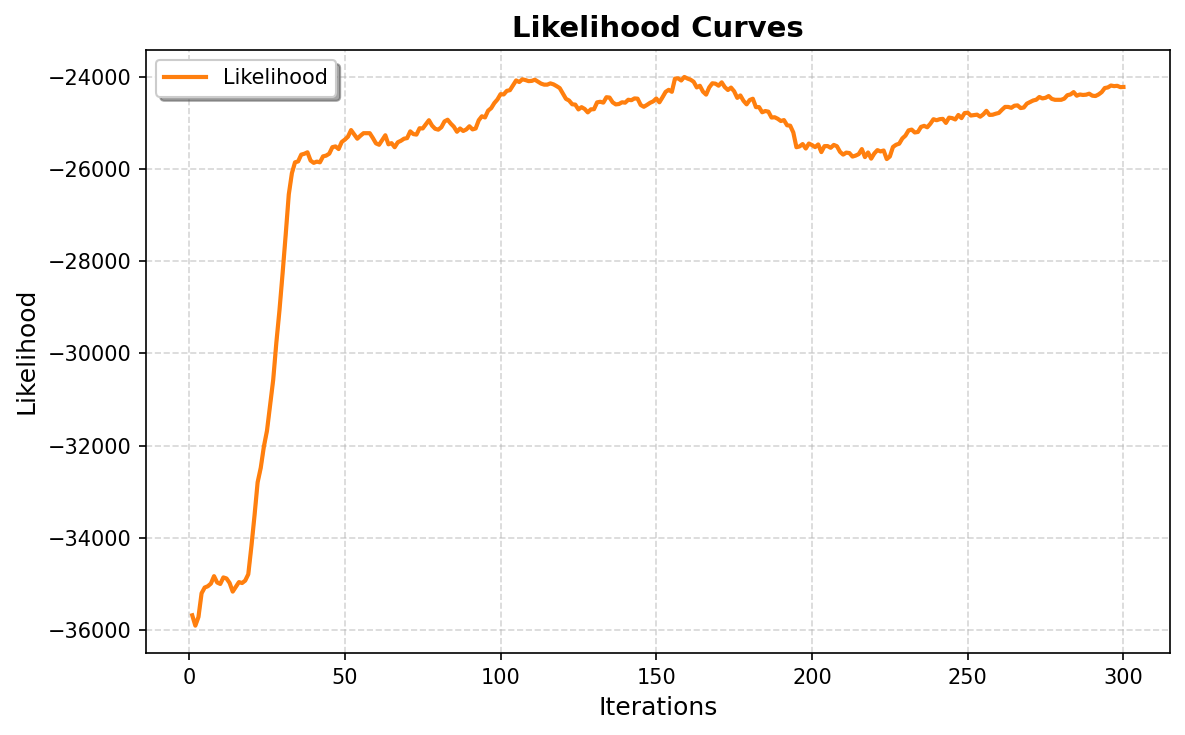

Gibbs Sampling (Iter 299) LogProb -24216.03: 100%|██████████| 300/300 [00:24<00:00, 12.39it/s]


Inference completed.


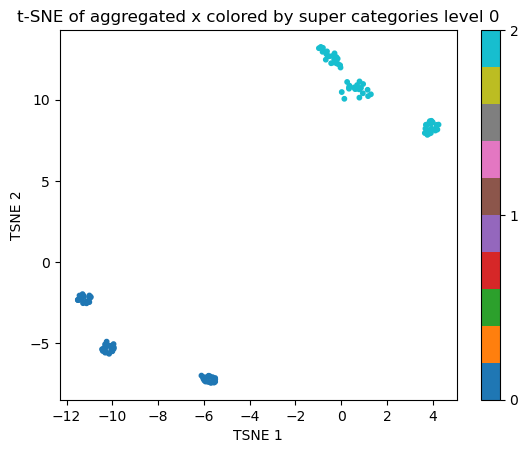

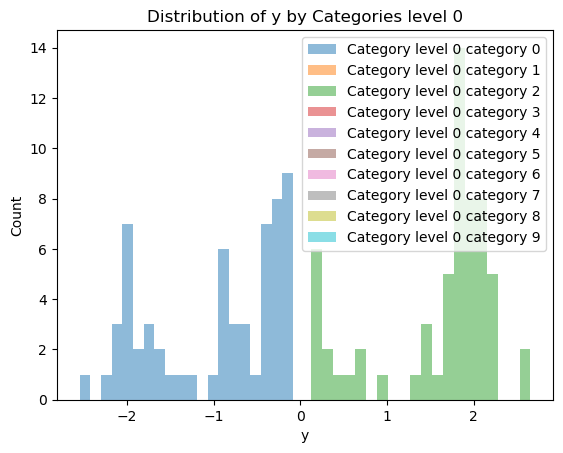

Initialized gamma: 0.7175
Initialized alpha0: Parameter containing:
tensor([0.6796, 0.6796, 0.6796, 0.6796, 0.6796, 0.6796, 0.6796, 0.6796, 0.6796,
        0.6796], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -31562.64:  99%|█████████▉| 298/300 [00:24<00:00, 12.25it/s]

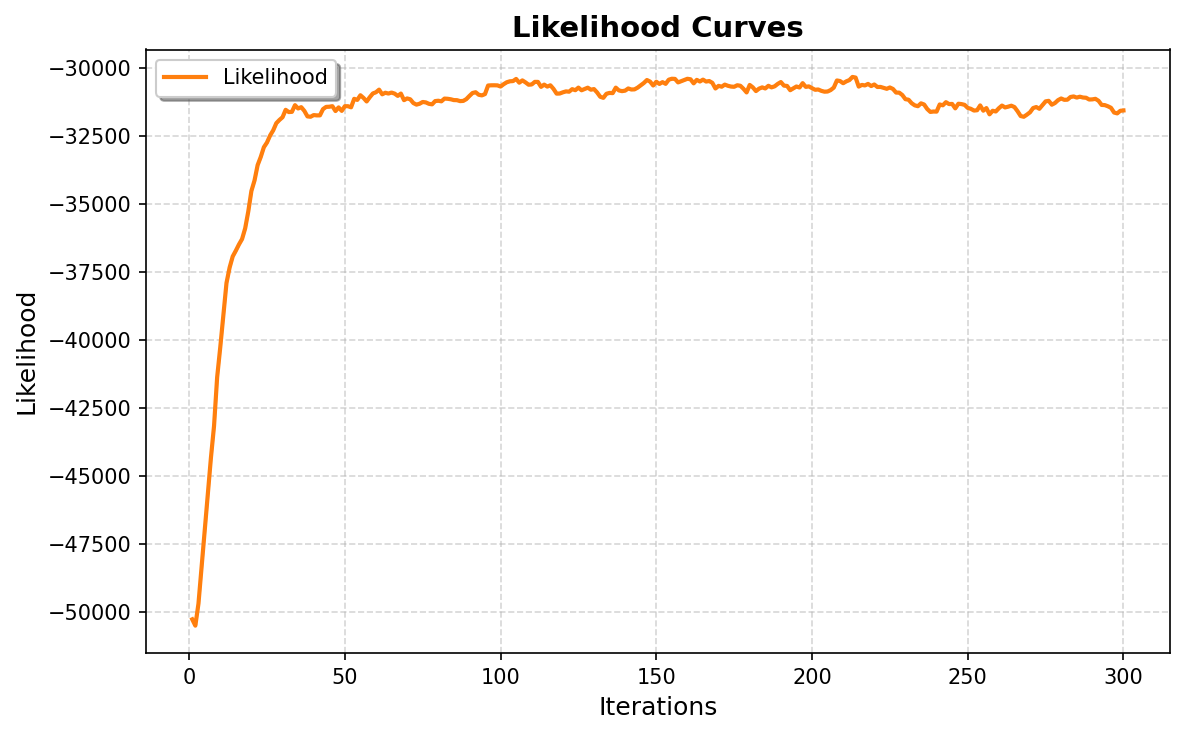

Gibbs Sampling (Iter 299) LogProb -31551.01: 100%|██████████| 300/300 [00:25<00:00, 11.94it/s]


Inference completed.


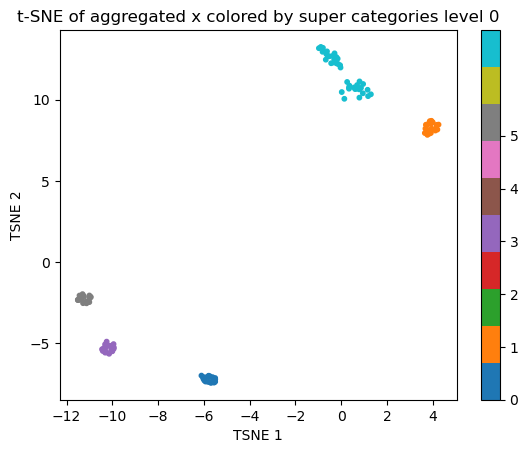

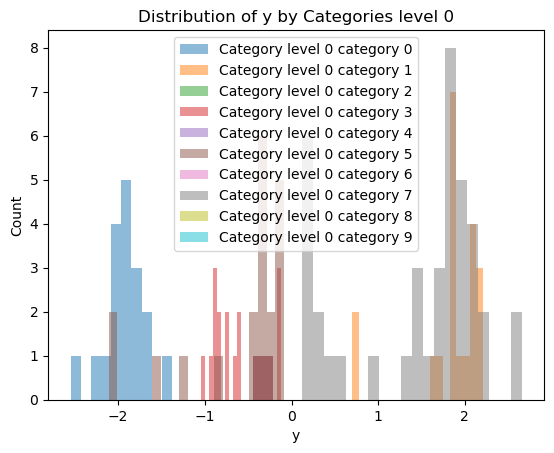

Initialized gamma: 0.8052
Initialized alpha0: Parameter containing:
tensor([0.5480, 0.5480, 0.5480, 0.5480, 0.5480, 0.5480, 0.5480, 0.5480, 0.5480,
        0.5480], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -30872.28:  99%|█████████▉| 298/300 [00:24<00:00, 12.03it/s]

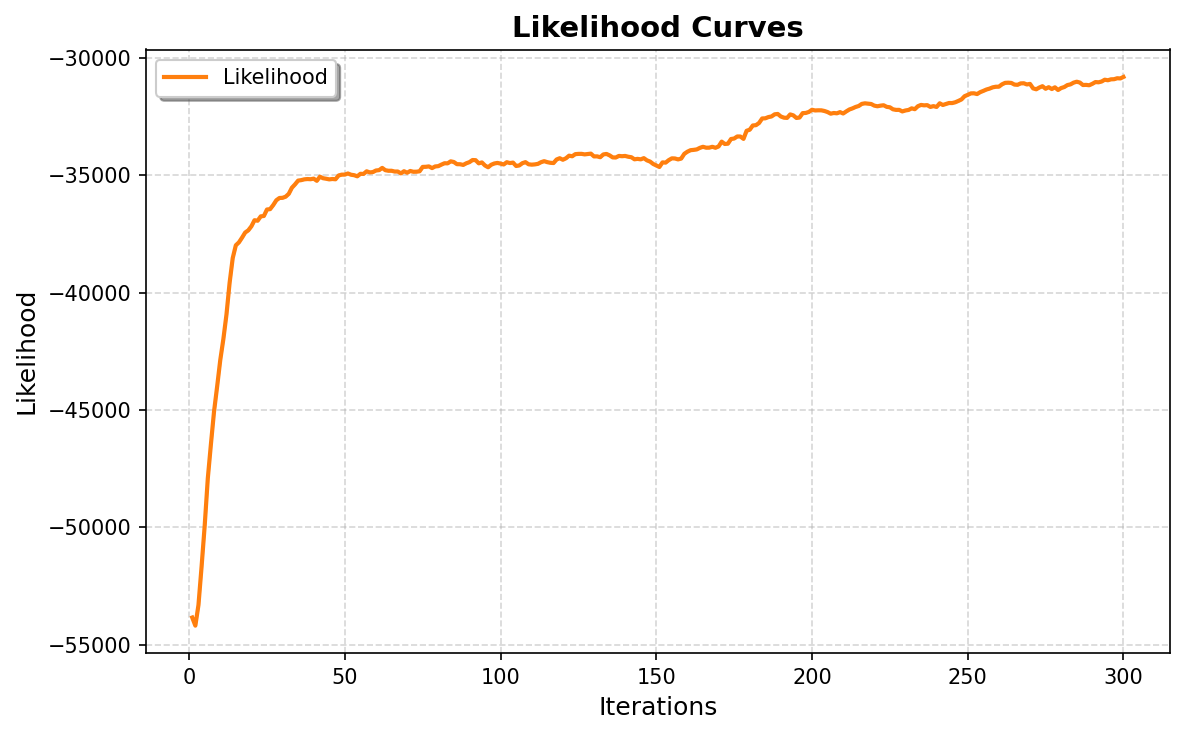

Gibbs Sampling (Iter 299) LogProb -30808.16: 100%|██████████| 300/300 [00:24<00:00, 12.01it/s]


Inference completed.


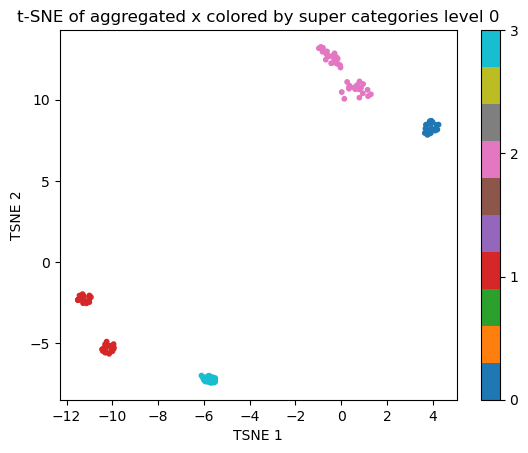

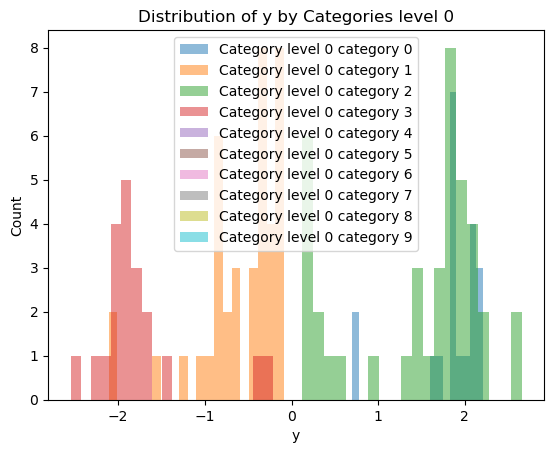

Initialized gamma: 0.5909
Initialized alpha0: Parameter containing:
tensor([0.8643, 0.8643, 0.8643, 0.8643, 0.8643, 0.8643, 0.8643, 0.8643, 0.8643,
        0.8643], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -29216.19:  99%|█████████▉| 298/300 [00:22<00:00, 12.56it/s]

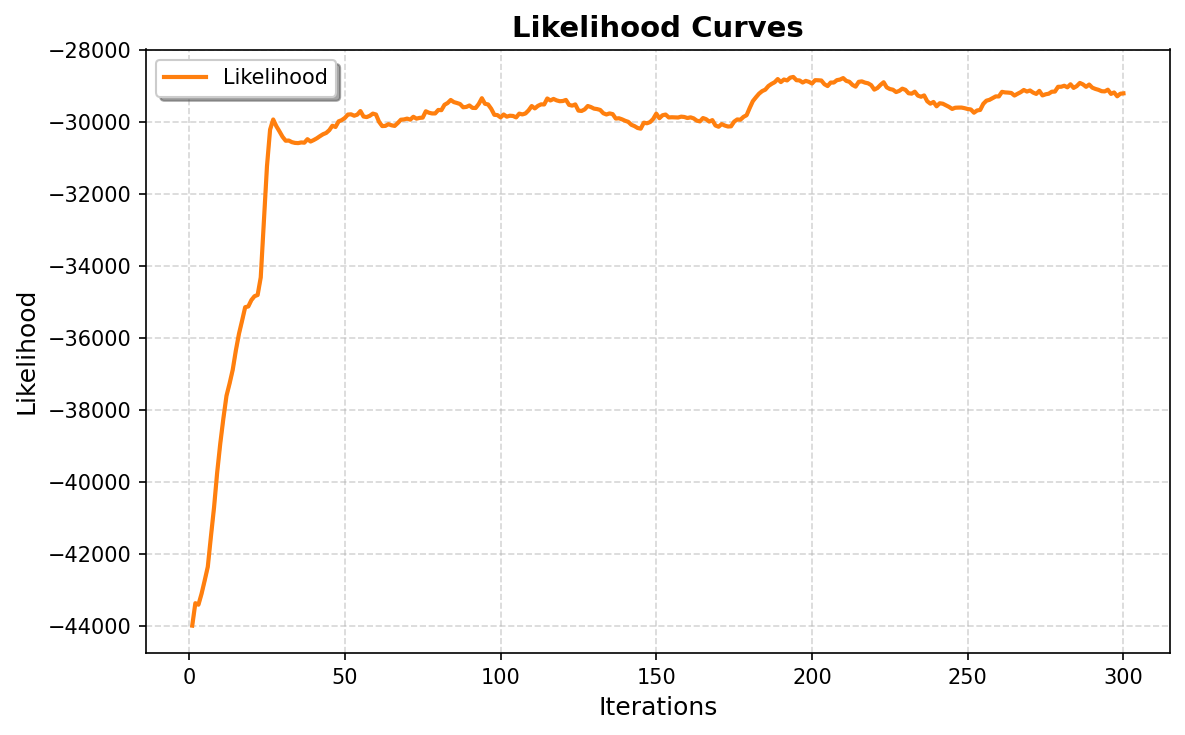

Gibbs Sampling (Iter 299) LogProb -29206.62: 100%|██████████| 300/300 [00:23<00:00, 12.96it/s]


Inference completed.


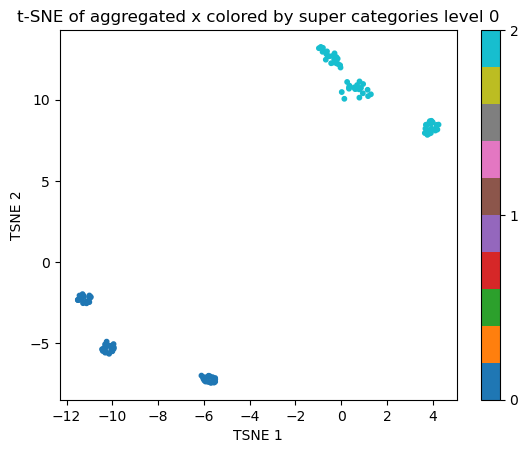

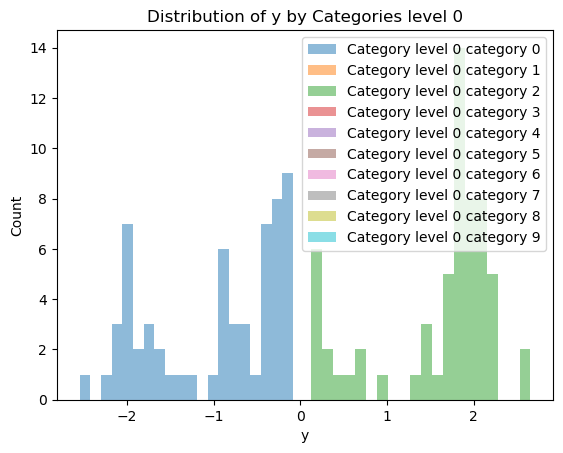

Initialized gamma: 0.5558
Initialized alpha0: Parameter containing:
tensor([0.9079, 0.9079, 0.9079, 0.9079, 0.9079, 0.9079, 0.9079, 0.9079, 0.9079,
        0.9079], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -29514.58:  99%|█████████▉| 298/300 [00:24<00:00, 11.64it/s]

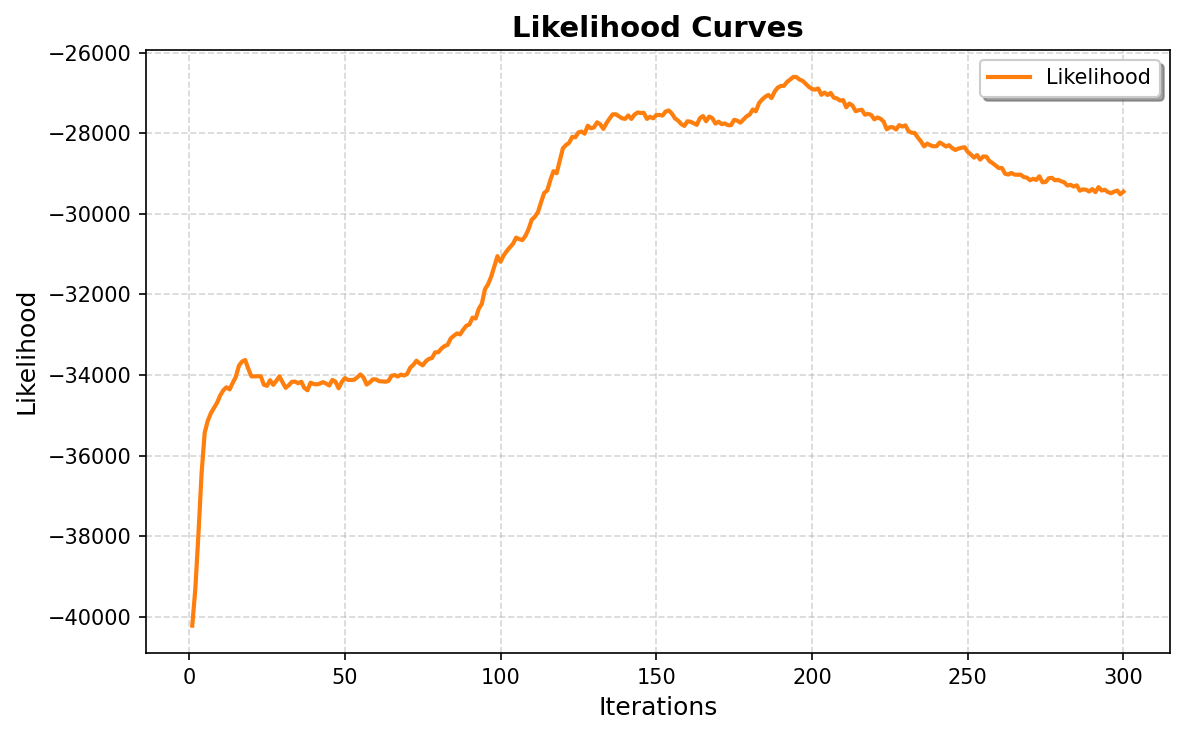

Gibbs Sampling (Iter 299) LogProb -29447.22: 100%|██████████| 300/300 [00:24<00:00, 12.10it/s]


Inference completed.


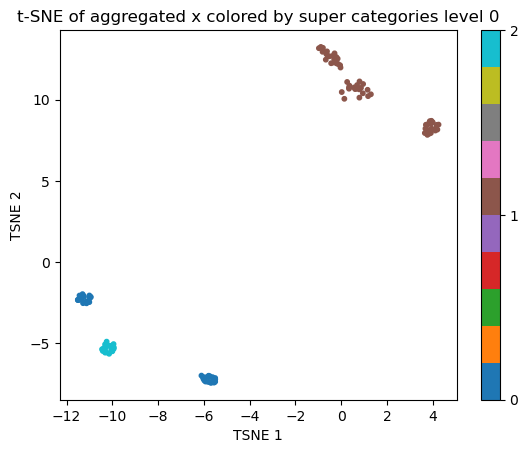

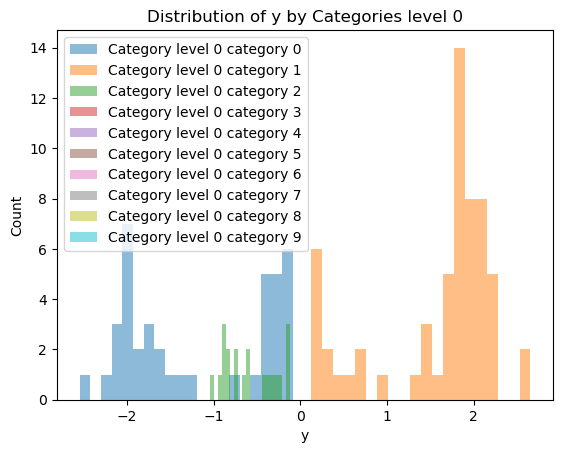

Initialized gamma: 0.8555
Initialized alpha0: Parameter containing:
tensor([0.5452, 0.5452, 0.5452, 0.5452, 0.5452, 0.5452, 0.5452, 0.5452, 0.5452,
        0.5452], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -30396.44:  99%|█████████▉| 298/300 [00:24<00:00, 11.66it/s]

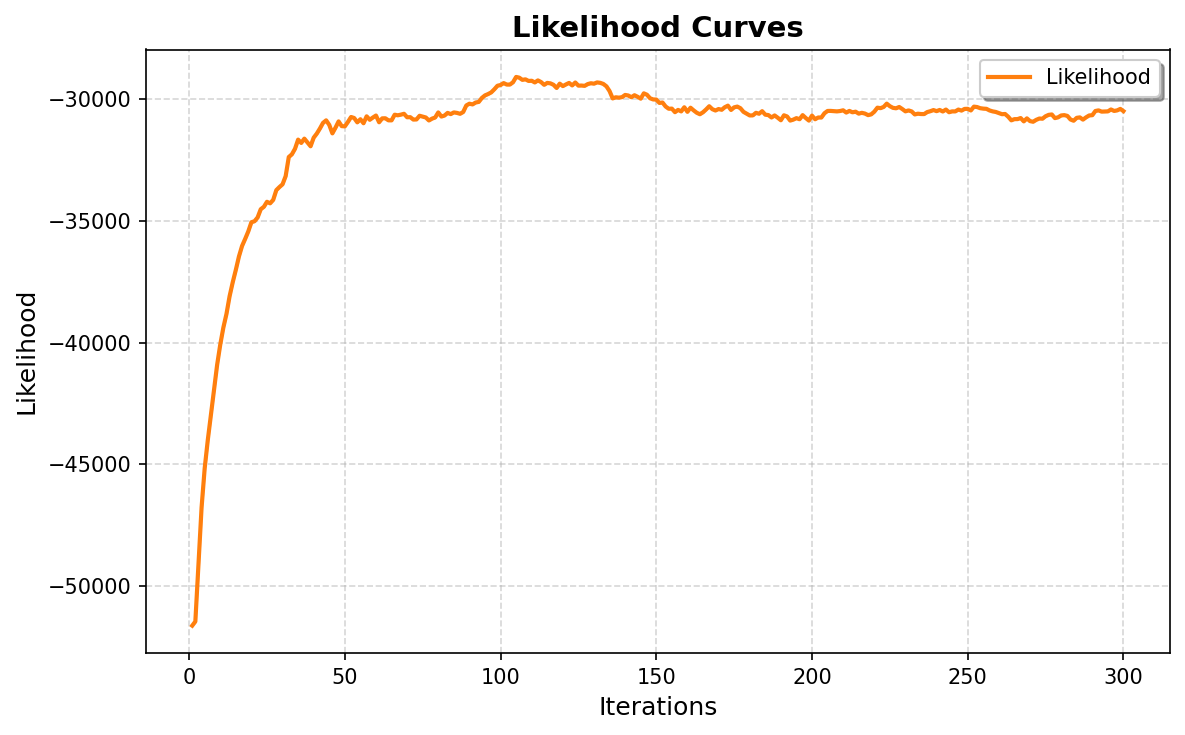

Gibbs Sampling (Iter 299) LogProb -30487.61: 100%|██████████| 300/300 [00:25<00:00, 11.94it/s]


Inference completed.


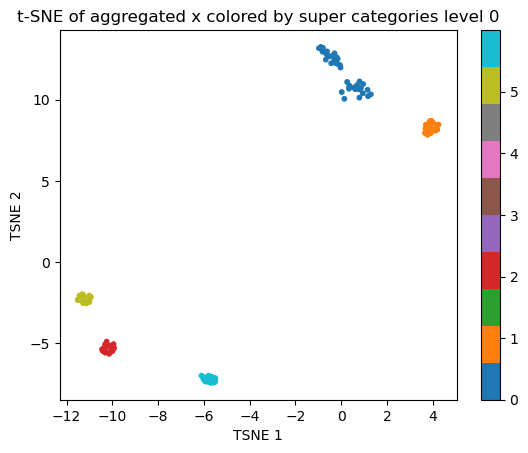

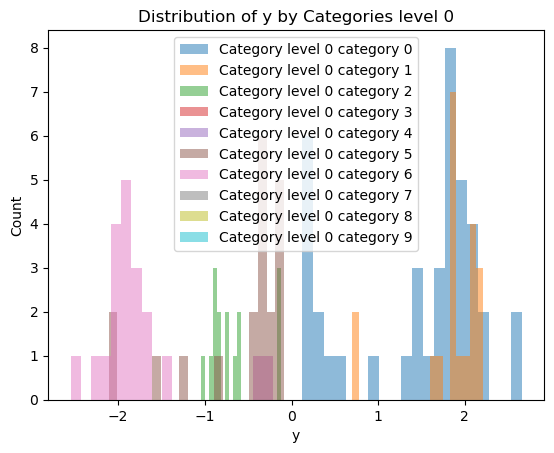

Initialized gamma: 0.7783
Initialized alpha0: Parameter containing:
tensor([0.7903, 0.7903, 0.7903, 0.7903, 0.7903, 0.7903, 0.7903, 0.7903, 0.7903,
        0.7903], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -33525.83:  99%|█████████▉| 298/300 [00:24<00:00, 11.99it/s]

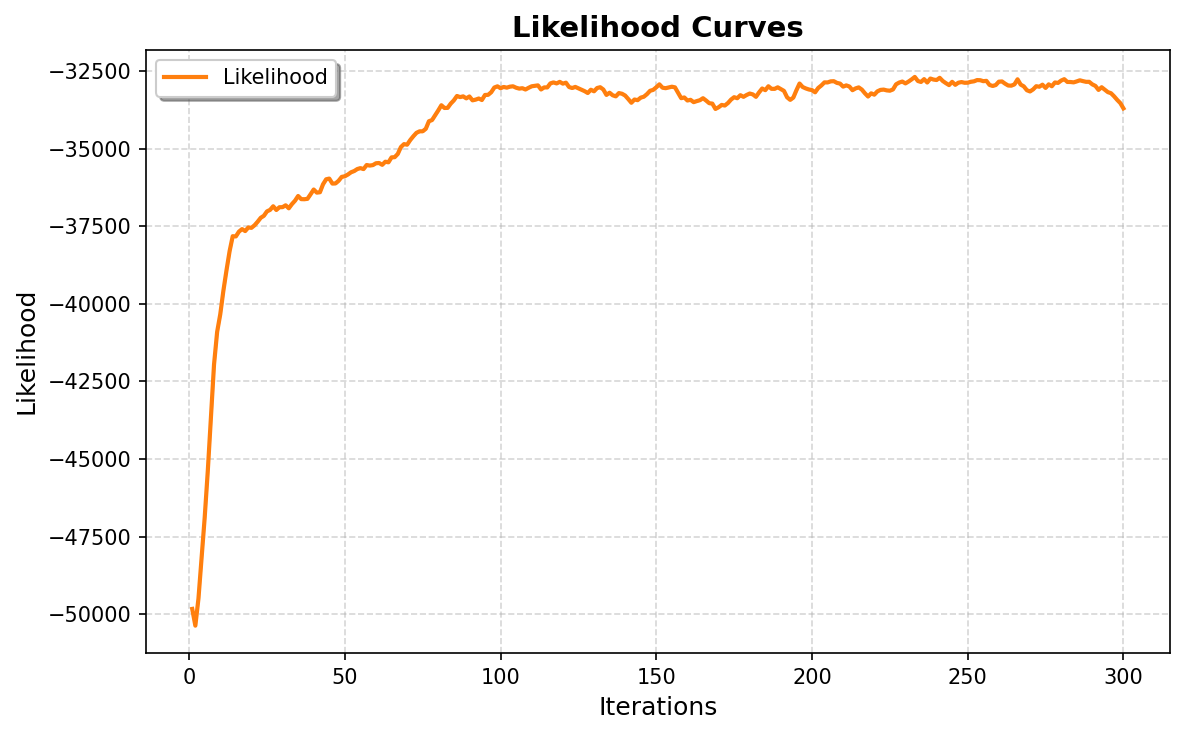

Gibbs Sampling (Iter 299) LogProb -33695.73: 100%|██████████| 300/300 [00:24<00:00, 12.16it/s]


Inference completed.


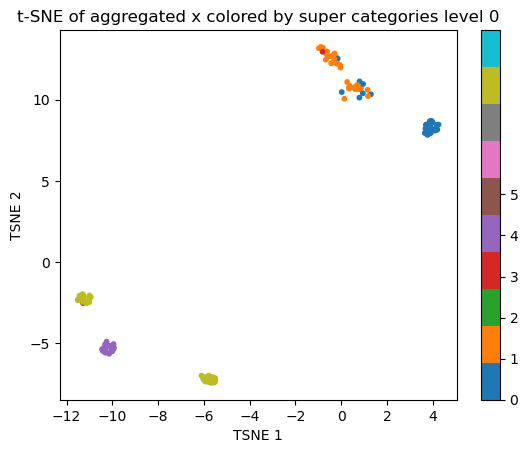

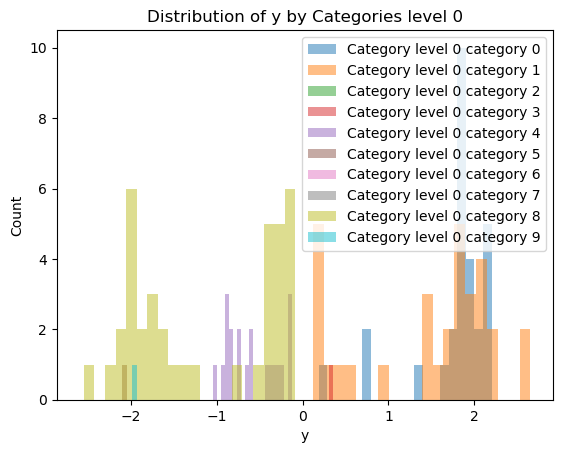

Initialized gamma: 0.6287
Initialized alpha0: Parameter containing:
tensor([0.7331, 0.7331, 0.7331, 0.7331, 0.7331, 0.7331, 0.7331, 0.7331, 0.7331,
        0.7331], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -32037.38:  99%|█████████▉| 298/300 [00:24<00:00, 12.11it/s]

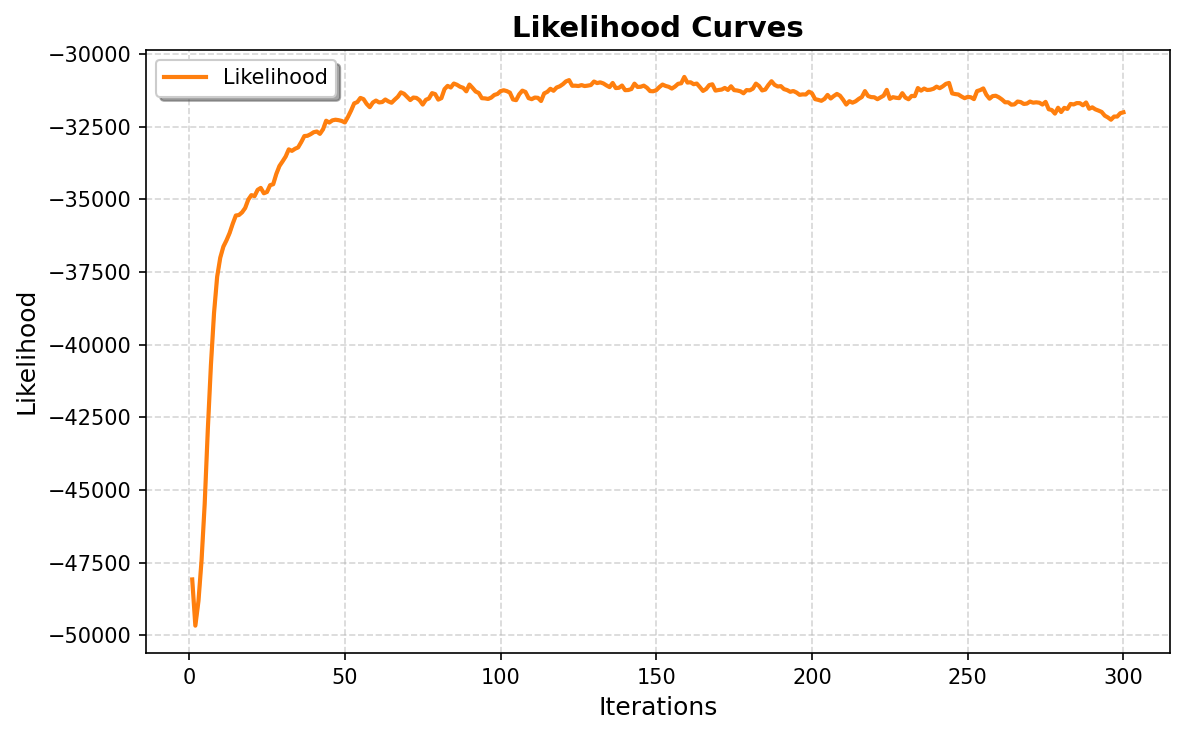

Gibbs Sampling (Iter 299) LogProb -32006.83: 100%|██████████| 300/300 [00:24<00:00, 12.30it/s]


Inference completed.


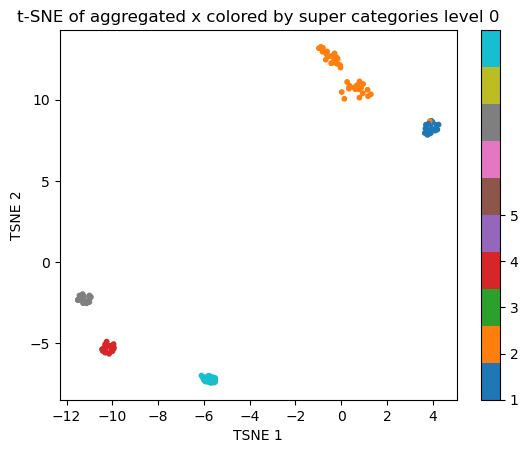

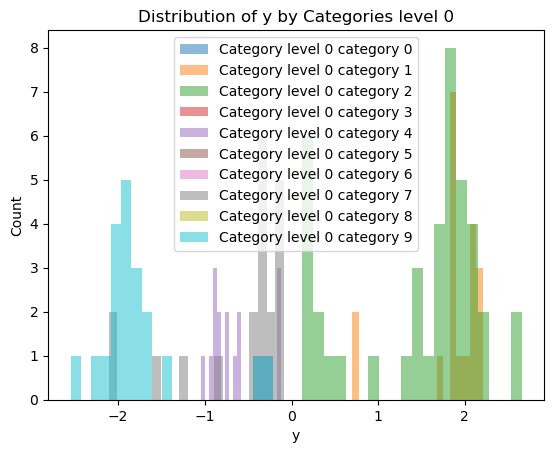

Initialized gamma: 0.7319
Initialized alpha0: Parameter containing:
tensor([0.8993, 0.8993, 0.8993, 0.8993, 0.8993, 0.8993, 0.8993, 0.8993, 0.8993,
        0.8993], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -40254.61:  99%|█████████▉| 298/300 [00:24<00:00, 11.52it/s]

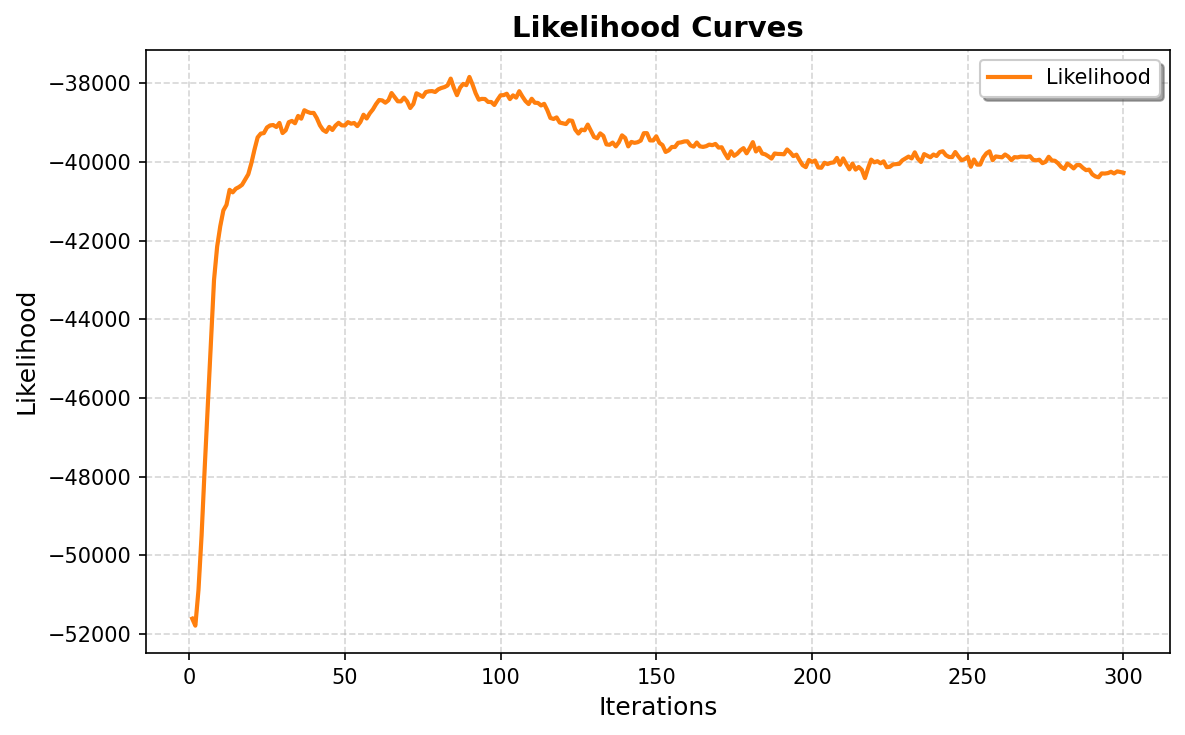

Gibbs Sampling (Iter 299) LogProb -40275.04: 100%|██████████| 300/300 [00:25<00:00, 11.97it/s]


Inference completed.


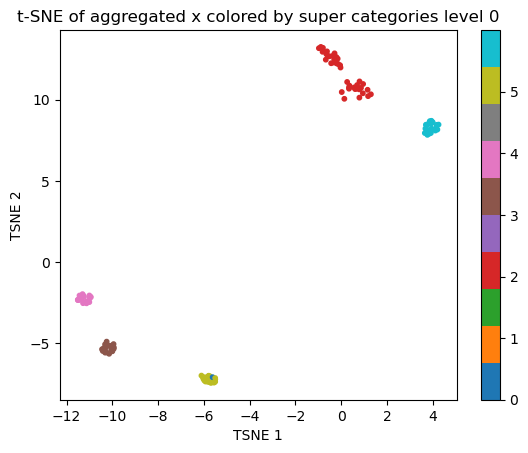

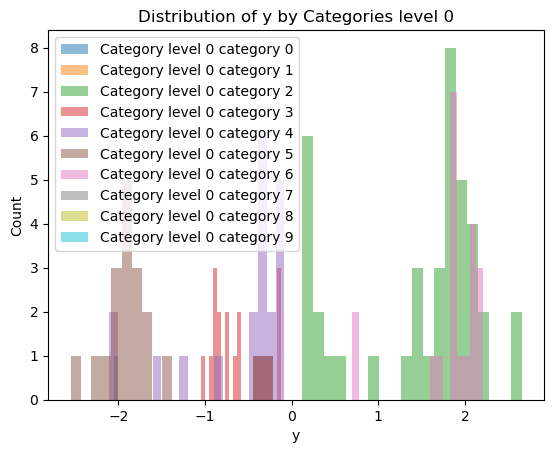

Initialized gamma: 0.7987
Initialized alpha0: Parameter containing:
tensor([0.7723, 0.7723, 0.7723, 0.7723, 0.7723, 0.7723, 0.7723, 0.7723, 0.7723,
        0.7723], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -36718.37:  99%|█████████▉| 298/300 [00:23<00:00, 12.49it/s]

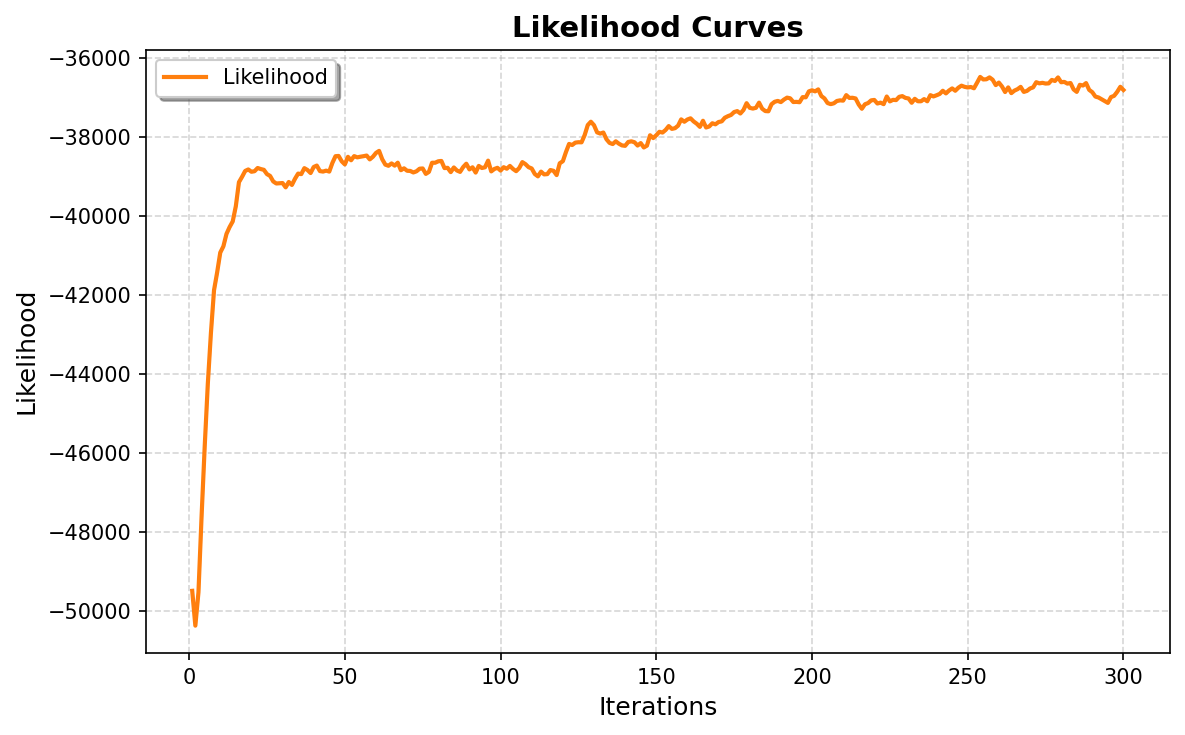

Gibbs Sampling (Iter 299) LogProb -36799.11: 100%|██████████| 300/300 [00:24<00:00, 12.46it/s]


Inference completed.


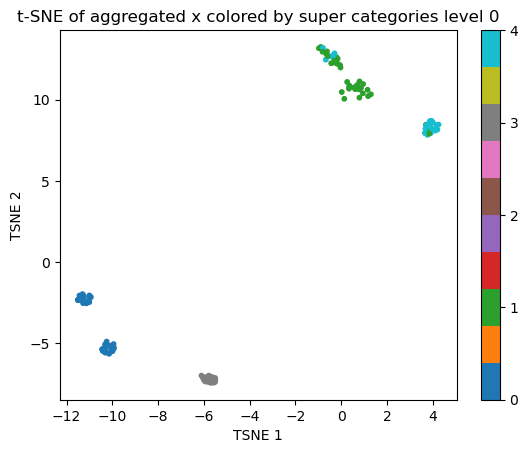

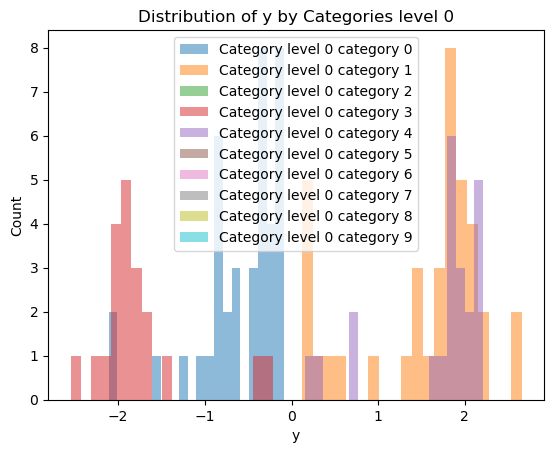

Initialized gamma: 0.6743
Initialized alpha0: Parameter containing:
tensor([0.9610, 0.9610, 0.9610, 0.9610, 0.9610, 0.9610, 0.9610, 0.9610, 0.9610,
        0.9610], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -31169.85:  99%|█████████▉| 298/300 [00:24<00:00, 11.64it/s]

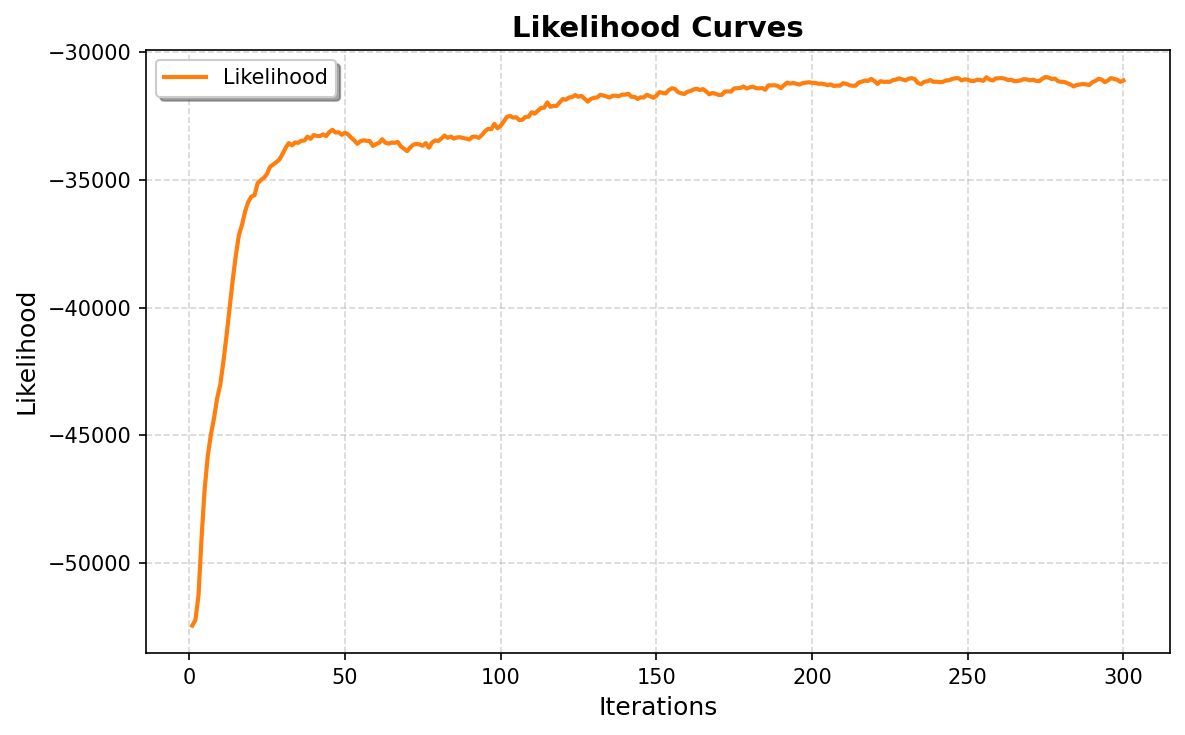

Gibbs Sampling (Iter 299) LogProb -31116.02: 100%|██████████| 300/300 [00:24<00:00, 12.03it/s]


Inference completed.


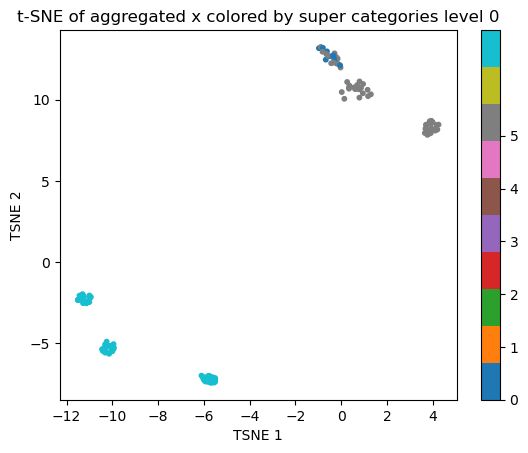

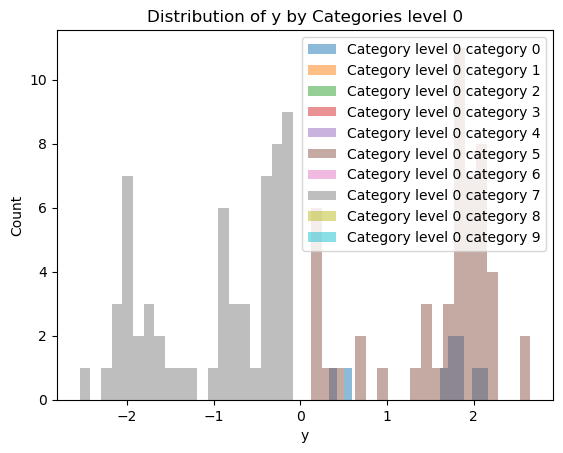

Initialized gamma: 0.7386
Initialized alpha0: Parameter containing:
tensor([0.9672, 0.9672, 0.9672, 0.9672, 0.9672, 0.9672, 0.9672, 0.9672, 0.9672,
        0.9672], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -34984.33:  99%|█████████▉| 298/300 [00:25<00:00, 11.85it/s]

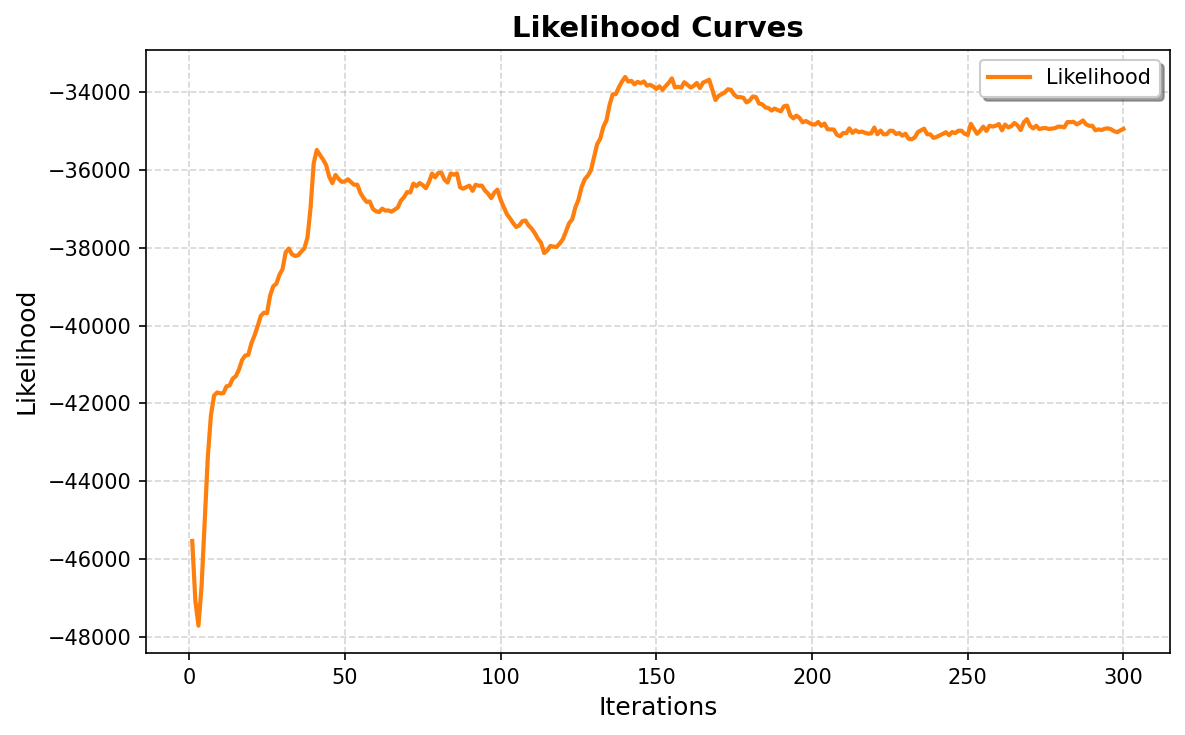

Gibbs Sampling (Iter 299) LogProb -34945.52: 100%|██████████| 300/300 [00:25<00:00, 11.90it/s]


Inference completed.


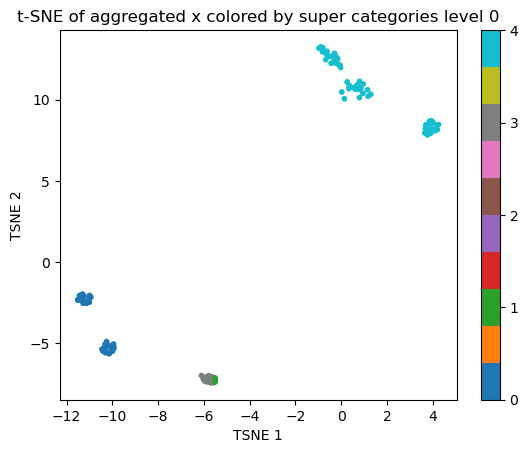

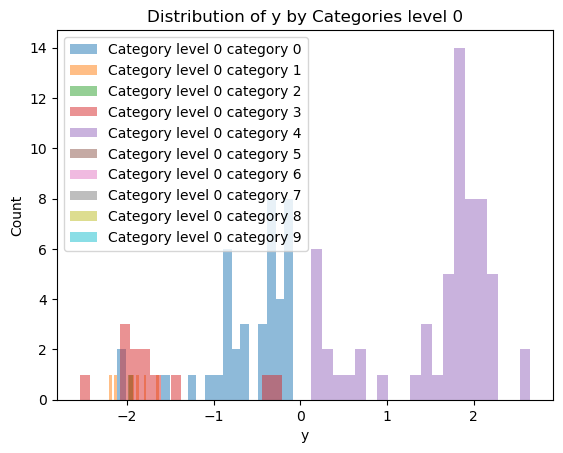

Initialized gamma: 0.5286
Initialized alpha0: Parameter containing:
tensor([0.5724, 0.5724, 0.5724, 0.5724, 0.5724, 0.5724, 0.5724, 0.5724, 0.5724,
        0.5724], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -35521.74:  99%|█████████▉| 298/300 [00:25<00:00, 11.91it/s]

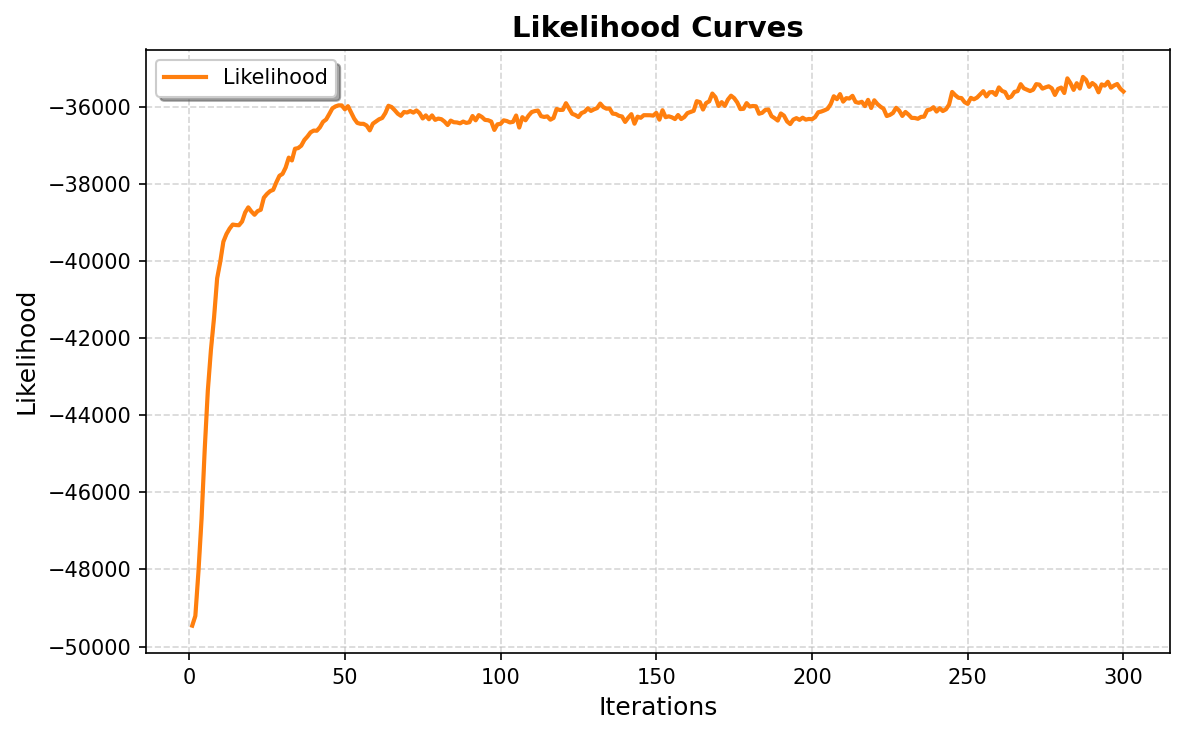

Gibbs Sampling (Iter 299) LogProb -35594.36: 100%|██████████| 300/300 [00:25<00:00, 11.86it/s]


Inference completed.


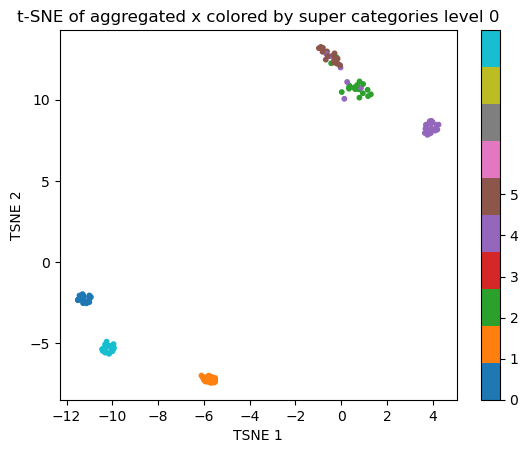

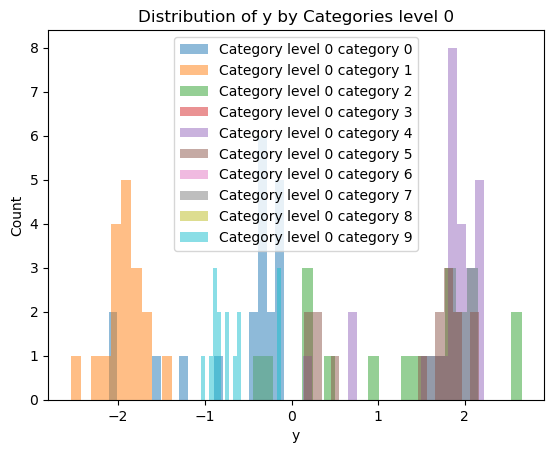

Initialized gamma: 0.8764
Initialized alpha0: Parameter containing:
tensor([0.5276, 0.5276, 0.5276, 0.5276, 0.5276, 0.5276, 0.5276, 0.5276, 0.5276,
        0.5276], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -37004.82:  99%|█████████▉| 298/300 [00:24<00:00, 12.53it/s]

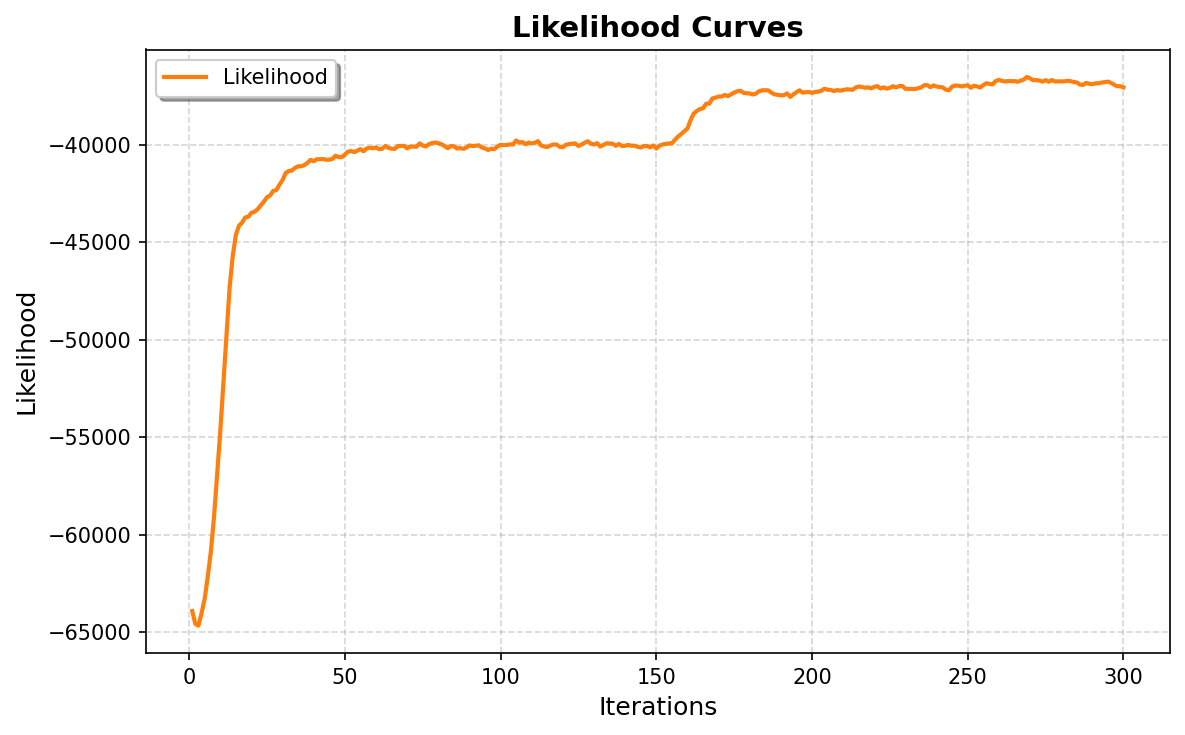

Gibbs Sampling (Iter 299) LogProb -37066.49: 100%|██████████| 300/300 [00:24<00:00, 12.21it/s]


Inference completed.


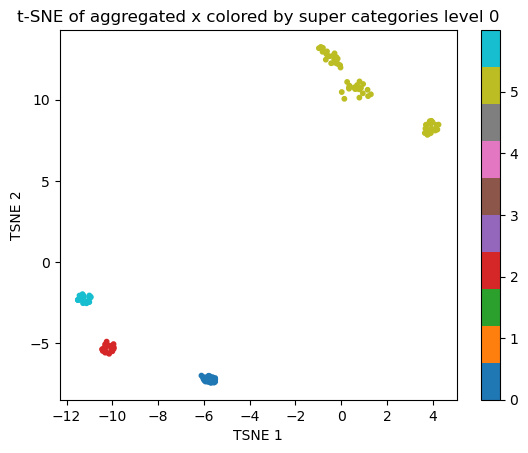

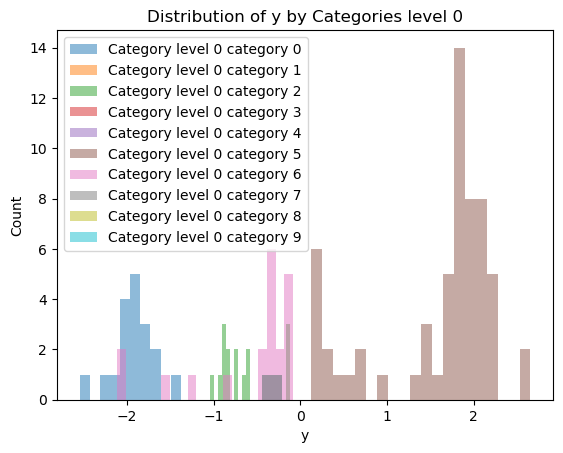

In [12]:
# struct_upbd = {"G0": 10, "G1": 2, "G2": 3}
struct_upbd = {"G0": 10, "G1": 10}
reserve_rate = [0, 0, 0]
for seed in range(10, 200, 10):
    model = HDMM(struct_upbd, vocab_size=100, device="cpu", seed=seed)
    print("Model initialized.")

    z_gen, z_reg, local_category_assignments, doc_values, log_prob = model.infer(torch.from_numpy(np.array(data["x"])).to(torch.float32), reg=torch.from_numpy(np.array(data["y"])).to(torch.float32), num_iters=300, plot_gap=300, reserve_rate=reserve_rate, heuristic_prelearn=False)
    print("Inference completed.")
    post_state = {
        "struct_params": model.struct_params,
        "struct_values": model.SV,
        "mixture_components": {
            "generation": model.mixture_components["generation"],
            "regression_mu": model.mixture_components["regression_mu"],
            "regression_sigma": model.mixture_components["regression_sigma"],
        },
        "local_category_assignments": local_category_assignments,
        "doc_values": None,
        "words": {
            "z_gen": z_gen,
            "z_reg": z_reg,
            "obs": data["x"],
            "reg": data["y"],
        },
    }
    model_return = (post_state, None)
    data_summary(model_return, data, struct_upbd, tsne=True, umap=False)

Initialized gamma: 0.7290
Initialized alpha0: Parameter containing:
tensor([0.7414, 0.7414, 0.7414, 0.7414, 0.7414, 0.7414, 0.7414, 0.7414, 0.7414,
        0.7414], requires_grad=True)
Initialized alpha1: Parameter containing:
tensor([[0.8075, 0.8075, 0.8075, 0.8075, 0.8075, 0.8075, 0.8075, 0.8075, 0.8075,
         0.8075],
        [0.6070, 0.6070, 0.6070, 0.6070, 0.6070, 0.6070, 0.6070, 0.6070, 0.6070,
         0.6070],
        [0.7059, 0.7059, 0.7059, 0.7059, 0.7059, 0.7059, 0.7059, 0.7059, 0.7059,
         0.7059],
        [0.8469, 0.8469, 0.8469, 0.8469, 0.8469, 0.8469, 0.8469, 0.8469, 0.8469,
         0.8469]], requires_grad=True)
Model initialized.


Gibbs Sampling:   0%|          | 0/300 [00:00<?, ?it/s]

Gibbs Sampling (Iter 298) LogProb -25330.28: 100%|█████████▉| 299/300 [00:23<00:00, 12.82it/s]

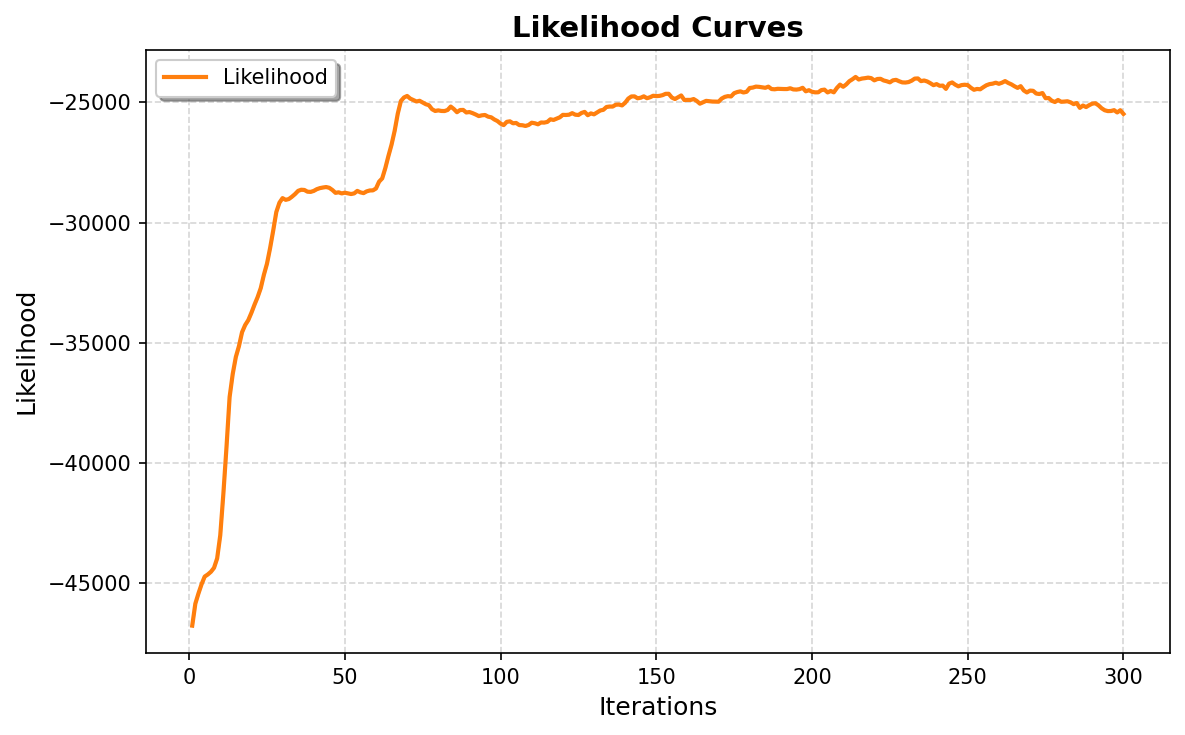

Gibbs Sampling (Iter 299) LogProb -25483.93: 100%|██████████| 300/300 [00:23<00:00, 12.53it/s]


Inference completed.


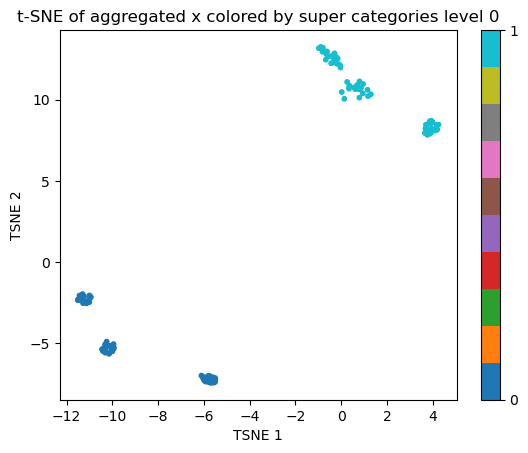

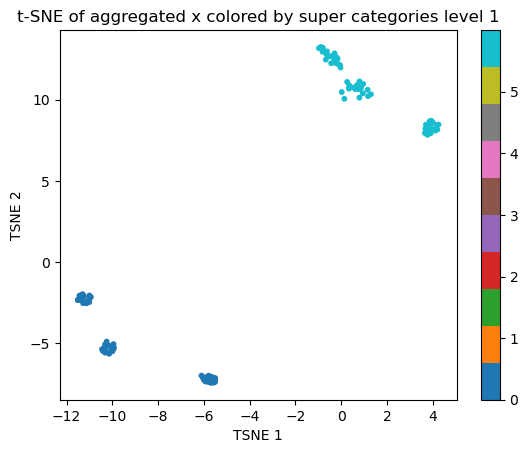

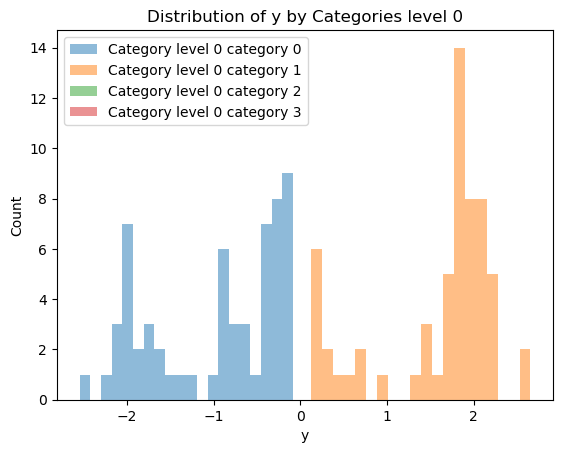

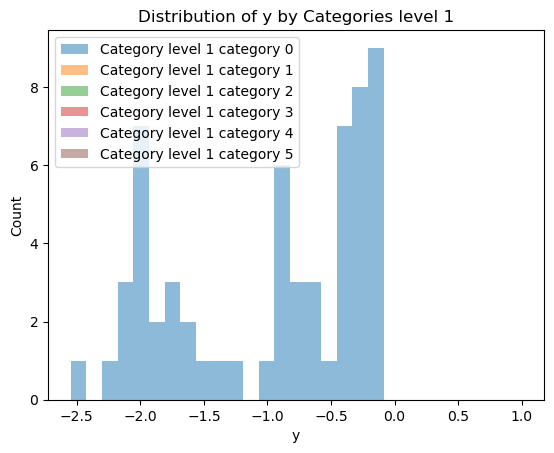

Initialized gamma: 0.7807
Initialized alpha0: Parameter containing:
tensor([0.5887, 0.5887, 0.5887, 0.5887, 0.5887, 0.5887, 0.5887, 0.5887, 0.5887,
        0.5887], requires_grad=True)
Initialized alpha1: Parameter containing:
tensor([[0.6648, 0.6648, 0.6648, 0.6648, 0.6648, 0.6648, 0.6648, 0.6648, 0.6648,
         0.6648],
        [0.6159, 0.6159, 0.6159, 0.6159, 0.6159, 0.6159, 0.6159, 0.6159, 0.6159,
         0.6159],
        [0.8916, 0.8916, 0.8916, 0.8916, 0.8916, 0.8916, 0.8916, 0.8916, 0.8916,
         0.8916],
        [0.9272, 0.9272, 0.9272, 0.9272, 0.9272, 0.9272, 0.9272, 0.9272, 0.9272,
         0.9272]], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -35688.63:  99%|█████████▉| 298/300 [00:23<00:00, 12.63it/s]

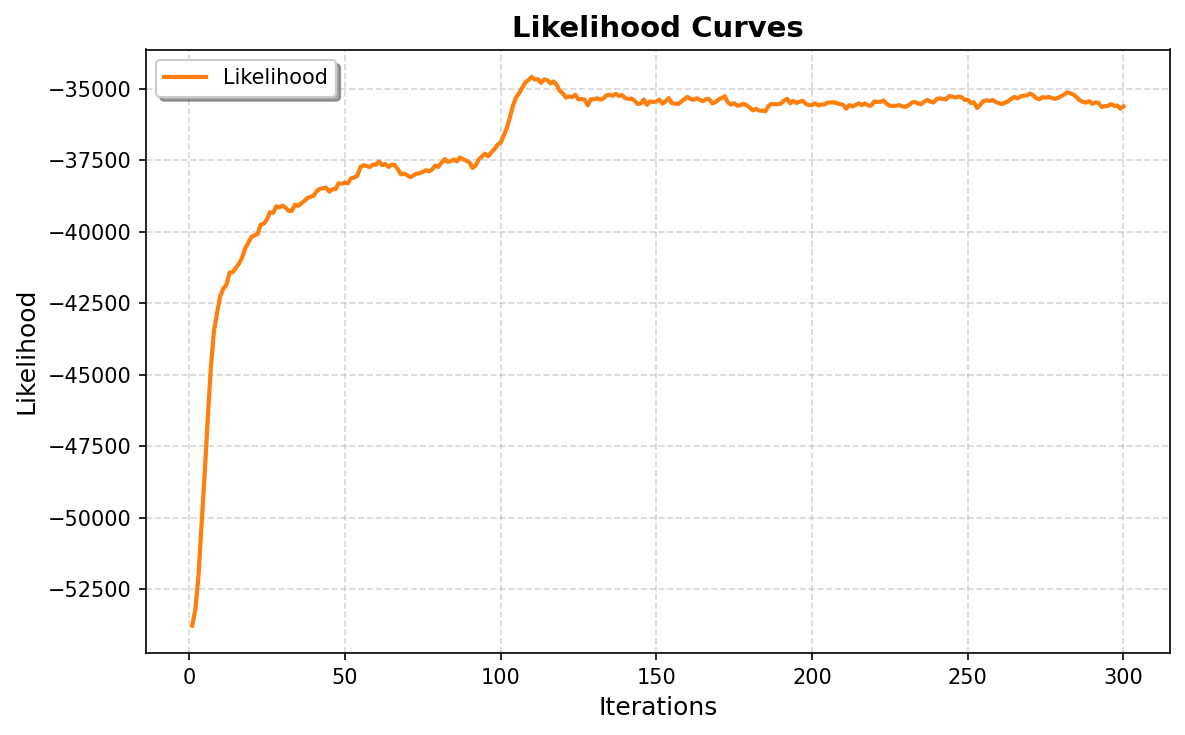

Gibbs Sampling (Iter 299) LogProb -35611.50: 100%|██████████| 300/300 [00:23<00:00, 12.51it/s]


Inference completed.


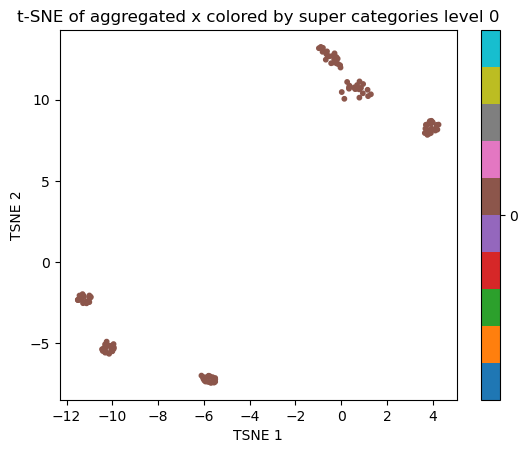

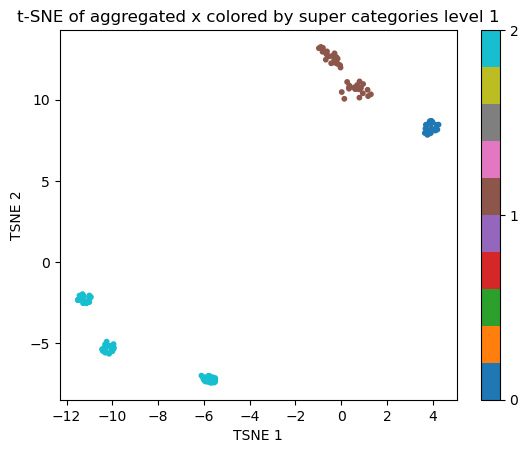

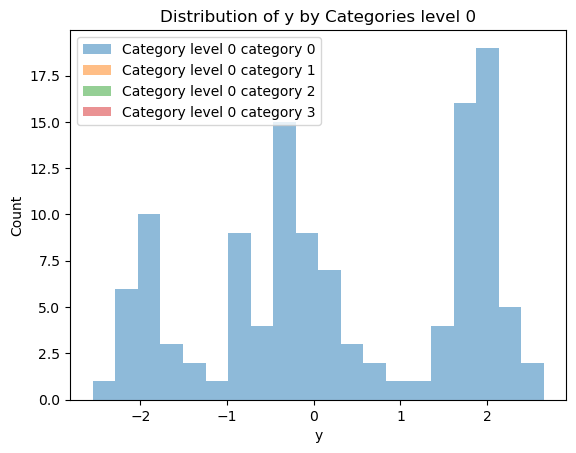

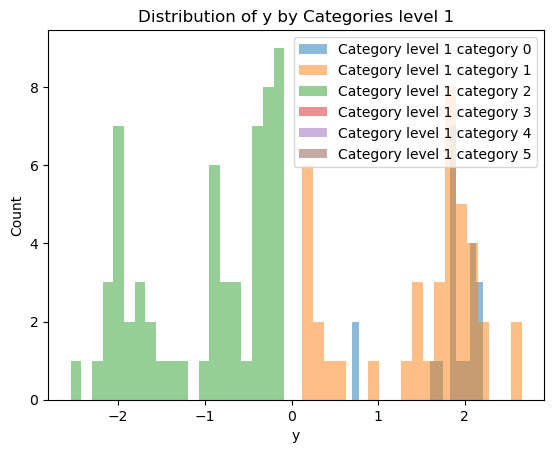

Initialized gamma: 0.9504
Initialized alpha0: Parameter containing:
tensor([0.8732, 0.8732, 0.8732, 0.8732, 0.8732, 0.8732, 0.8732, 0.8732, 0.8732,
        0.8732], requires_grad=True)
Initialized alpha1: Parameter containing:
tensor([[0.9369, 0.9369, 0.9369, 0.9369, 0.9369, 0.9369, 0.9369, 0.9369, 0.9369,
         0.9369],
        [0.8701, 0.8701, 0.8701, 0.8701, 0.8701, 0.8701, 0.8701, 0.8701, 0.8701,
         0.8701],
        [0.8920, 0.8920, 0.8920, 0.8920, 0.8920, 0.8920, 0.8920, 0.8920, 0.8920,
         0.8920],
        [0.9473, 0.9473, 0.9473, 0.9473, 0.9473, 0.9473, 0.9473, 0.9473, 0.9473,
         0.9473]], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -44515.75:  99%|█████████▉| 298/300 [00:22<00:00, 12.01it/s]

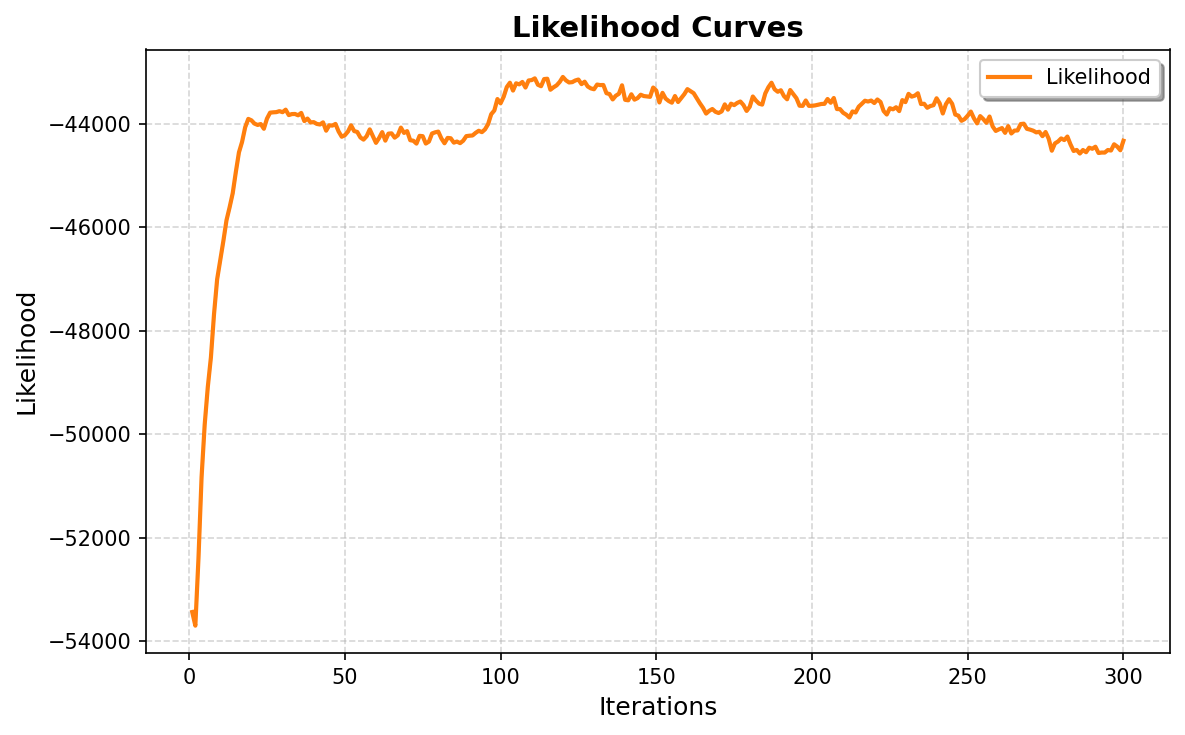

Gibbs Sampling (Iter 299) LogProb -44332.20: 100%|██████████| 300/300 [00:23<00:00, 12.96it/s]


Inference completed.


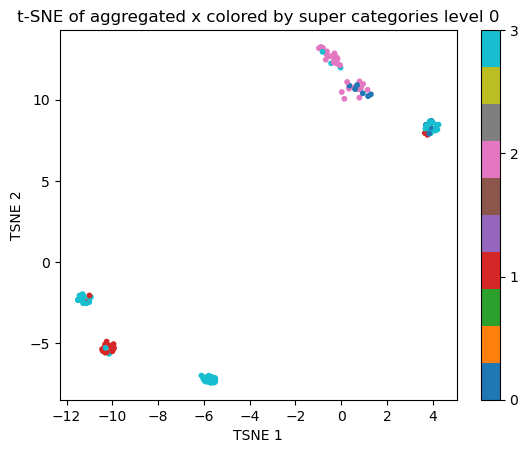

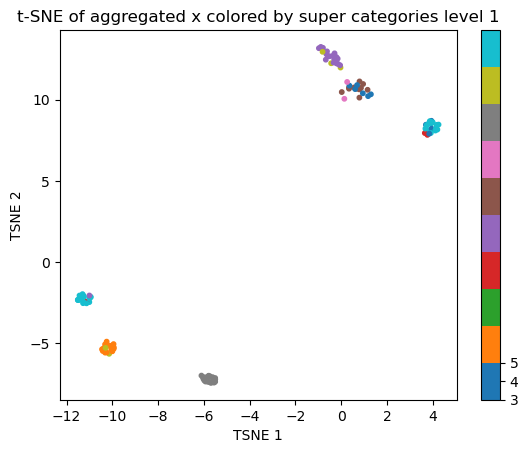

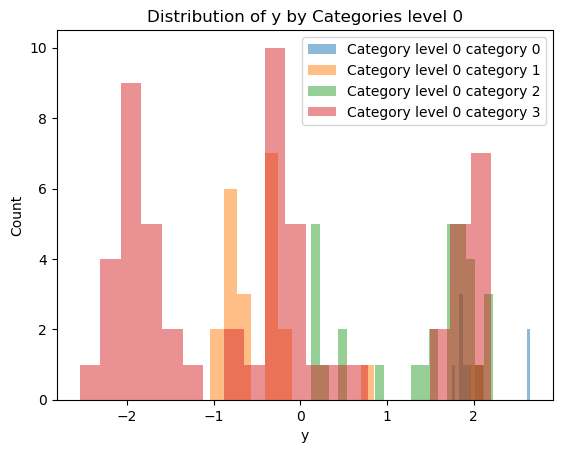

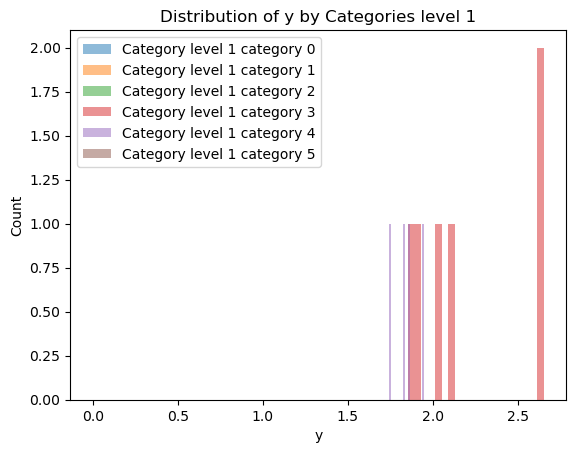

Initialized gamma: 0.6839
Initialized alpha0: Parameter containing:
tensor([0.9331, 0.9331, 0.9331, 0.9331, 0.9331, 0.9331, 0.9331, 0.9331, 0.9331,
        0.9331], requires_grad=True)
Initialized alpha1: Parameter containing:
tensor([[0.8579, 0.8579, 0.8579, 0.8579, 0.8579, 0.8579, 0.8579, 0.8579, 0.8579,
         0.8579],
        [0.9325, 0.9325, 0.9325, 0.9325, 0.9325, 0.9325, 0.9325, 0.9325, 0.9325,
         0.9325],
        [0.7439, 0.7439, 0.7439, 0.7439, 0.7439, 0.7439, 0.7439, 0.7439, 0.7439,
         0.7439],
        [0.7751, 0.7751, 0.7751, 0.7751, 0.7751, 0.7751, 0.7751, 0.7751, 0.7751,
         0.7751]], requires_grad=True)
Model initialized.


Gibbs Sampling (Iter 298) LogProb -33468.43:  99%|█████████▉| 298/300 [00:25<00:00, 11.84it/s]

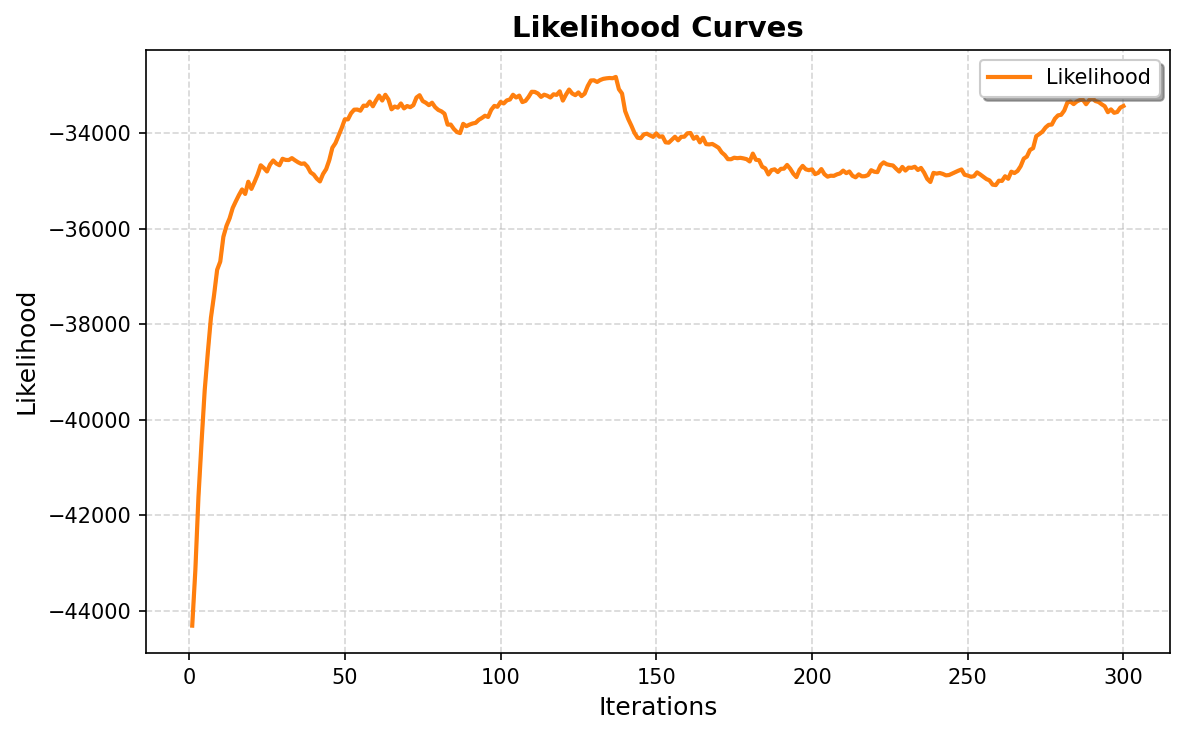

Gibbs Sampling (Iter 299) LogProb -33434.60: 100%|██████████| 300/300 [00:25<00:00, 11.78it/s]


Inference completed.


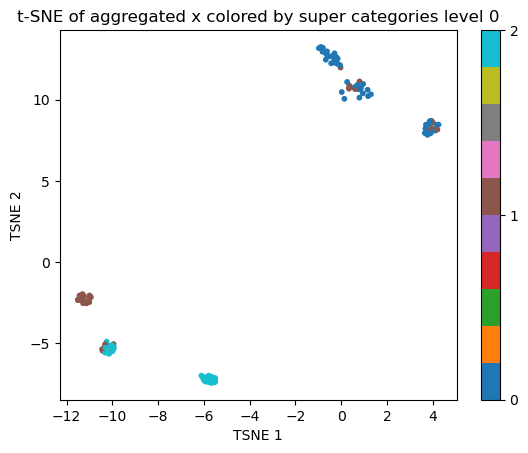

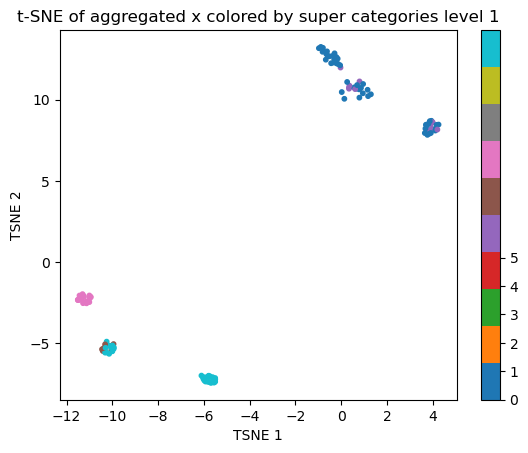

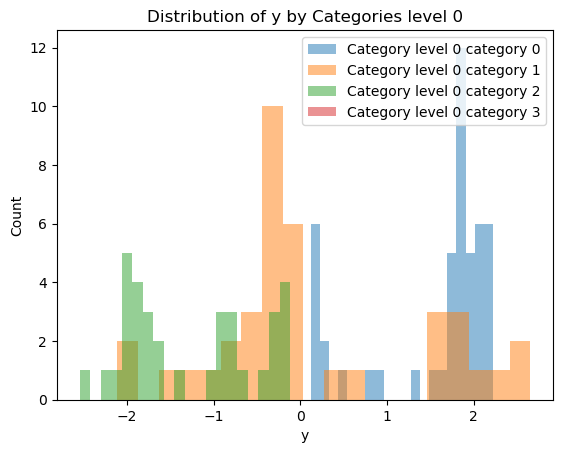

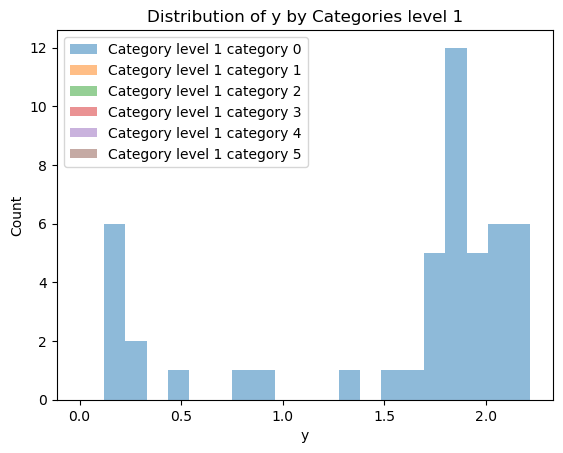

In [15]:
# struct_upbd = {"G0": 10, "G1": 2, "G2": 3}
struct_upbd = {"G0": 10, "G1": 4, "G2": 6}
reserve_rate = [0, 0, 0]
for seed in range(10, 50, 10):
    model = HDMM(struct_upbd, vocab_size=100, device="cpu", seed=seed)
    print("Model initialized.")

    z_gen, z_reg, local_category_assignments, doc_values, log_prob = model.infer(torch.from_numpy(np.array(data["x"])).to(torch.float32), reg=torch.from_numpy(np.array(data["y"])).to(torch.float32), num_iters=300, plot_gap=300, reserve_rate=reserve_rate, heuristic_prelearn=False)
    print("Inference completed.")
    post_state = {
        "struct_params": model.struct_params,
        "struct_values": model.SV,
        "mixture_components": {
            "generation": model.mixture_components["generation"],
            "regression_mu": model.mixture_components["regression_mu"],
            "regression_sigma": model.mixture_components["regression_sigma"],
        },
        "local_category_assignments": local_category_assignments,
        "doc_values": None,
        "words": {
            "z_gen": z_gen,
            "z_reg": z_reg,
            "obs": data["x"],
            "reg": data["y"],
        },
    }
    model_return = (post_state, None)
    data_summary(model_return, data, struct_upbd, tsne=True, umap=False)